In [1]:
pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [3]:
# Load dataset
df = pd.read_csv("dataset/ML-EdgeIIoT-dataset.csv")

# View basic info
print(df.shape)
df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25324\3855122037.py:2: DtypeWarning: Columns (3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset/ML-EdgeIIoT-dataset.csv")


(157800, 63)


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
3,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
4,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [4]:
target_col = "Attack_type"   # change if name differs

In [5]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# View class mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(class_mapping)

{'Backdoor': np.int64(0), 'DDoS_HTTP': np.int64(1), 'DDoS_ICMP': np.int64(2), 'DDoS_TCP': np.int64(3), 'DDoS_UDP': np.int64(4), 'Fingerprinting': np.int64(5), 'MITM': np.int64(6), 'Normal': np.int64(7), 'Password': np.int64(8), 'Port_Scanning': np.int64(9), 'Ransomware': np.int64(10), 'SQL_injection': np.int64(11), 'Uploading': np.int64(12), 'Vulnerability_scanner': np.int64(13), 'XSS': np.int64(14)}


In [8]:
attack_mapping = {
    'Normal': 'Normal',

    # DDoS attacks
    'DDoS_HTTP': 'DDoS',
    'DDoS_ICMP': 'DDoS',
    'DDoS_TCP': 'DDoS',
    'DDoS_UDP': 'DDoS',

    # DoS / Scanning
    'Port_Scanning': 'DoS_Scanning',
    'Fingerprinting': 'DoS_Scanning',
    'Vulnerability_scanner': 'DoS_Scanning',

    # Injection / Web attacks
    'SQL_injection': 'Injection',
    'XSS': 'Injection',
    'Uploading': 'Injection',

    # Malware / Credential attacks
    'Backdoor': 'Malware',
    'Ransomware': 'Malware',
    'Password': 'Malware',
    'MITM': 'Malware'
}

In [9]:
df['Attack_5Class'] = df['Attack_type'].map(attack_mapping)

In [10]:
print(df['Attack_5Class'].value_counts())

Attack_5Class
DDoS            49396
Malware         32323
Injection       30632
Normal          24301
DoS_Scanning    21148
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import LabelEncoder

le_5class = LabelEncoder()
y_5class = le_5class.fit_transform(df['Attack_5Class'])

print(dict(zip(le_5class.classes_, range(len(le_5class.classes_)))))

{'DDoS': 0, 'DoS_Scanning': 1, 'Injection': 2, 'Malware': 3, 'Normal': 4}


In [12]:
# Drop original labels, keep only features
X = df.drop(columns=['Attack_type', 'Attack_5Class'])

# Target (5-class)
y = y_5class

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (157800, 62)
Target shape : (157800,)


In [13]:
# STEP 7 (FIXED): Encode categorical features safely

from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)

for col in cat_cols:
    X[col] = X[col].astype(str)   # 🔑 FIX: force uniform type
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

Categorical columns: Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
       'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname',
       'mqtt.topic'],
      dtype='object')


In [14]:
# Fill missing values with median (edge-friendly)
X = X.fillna(X.median())

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from xgboost import XGBClassifier

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    
    # ✅ Proposed Model
    "Proposed XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

In [19]:
from sklearn.preprocessing import label_binarize

# Get number of classes
classes = np.unique(y_test)
n_classes = len(classes)

# Convert labels to one-hot format
y_test_bin = label_binarize(y_test, classes=classes)

models_probs = {}
models_ap = {}

for name, model in models.items():
    
    print(f"\nTraining {name}...")
    
    model.fit(X_train, y_train)
    
    # Get full probability matrix
    probs = model.predict_proba(X_test)
    
    models_probs[name] = probs
    
    # Compute macro-average precision
    ap = average_precision_score(
        y_test_bin,
        probs,
        average="macro"
    )
    
    models_ap[name] = ap
    
    print(f"{name} Macro Average Precision (AP): {ap:.4f}")


Training Logistic Regression...
Logistic Regression Macro Average Precision (AP): 0.9816

Training SVM...
SVM Macro Average Precision (AP): 0.9988

Training Random Forest...
Random Forest Macro Average Precision (AP): 1.0000

Training KNN...
KNN Macro Average Precision (AP): 0.9984

Training Proposed XGBoost...


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [08:54:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Proposed XGBoost Macro Average Precision (AP): 1.0000


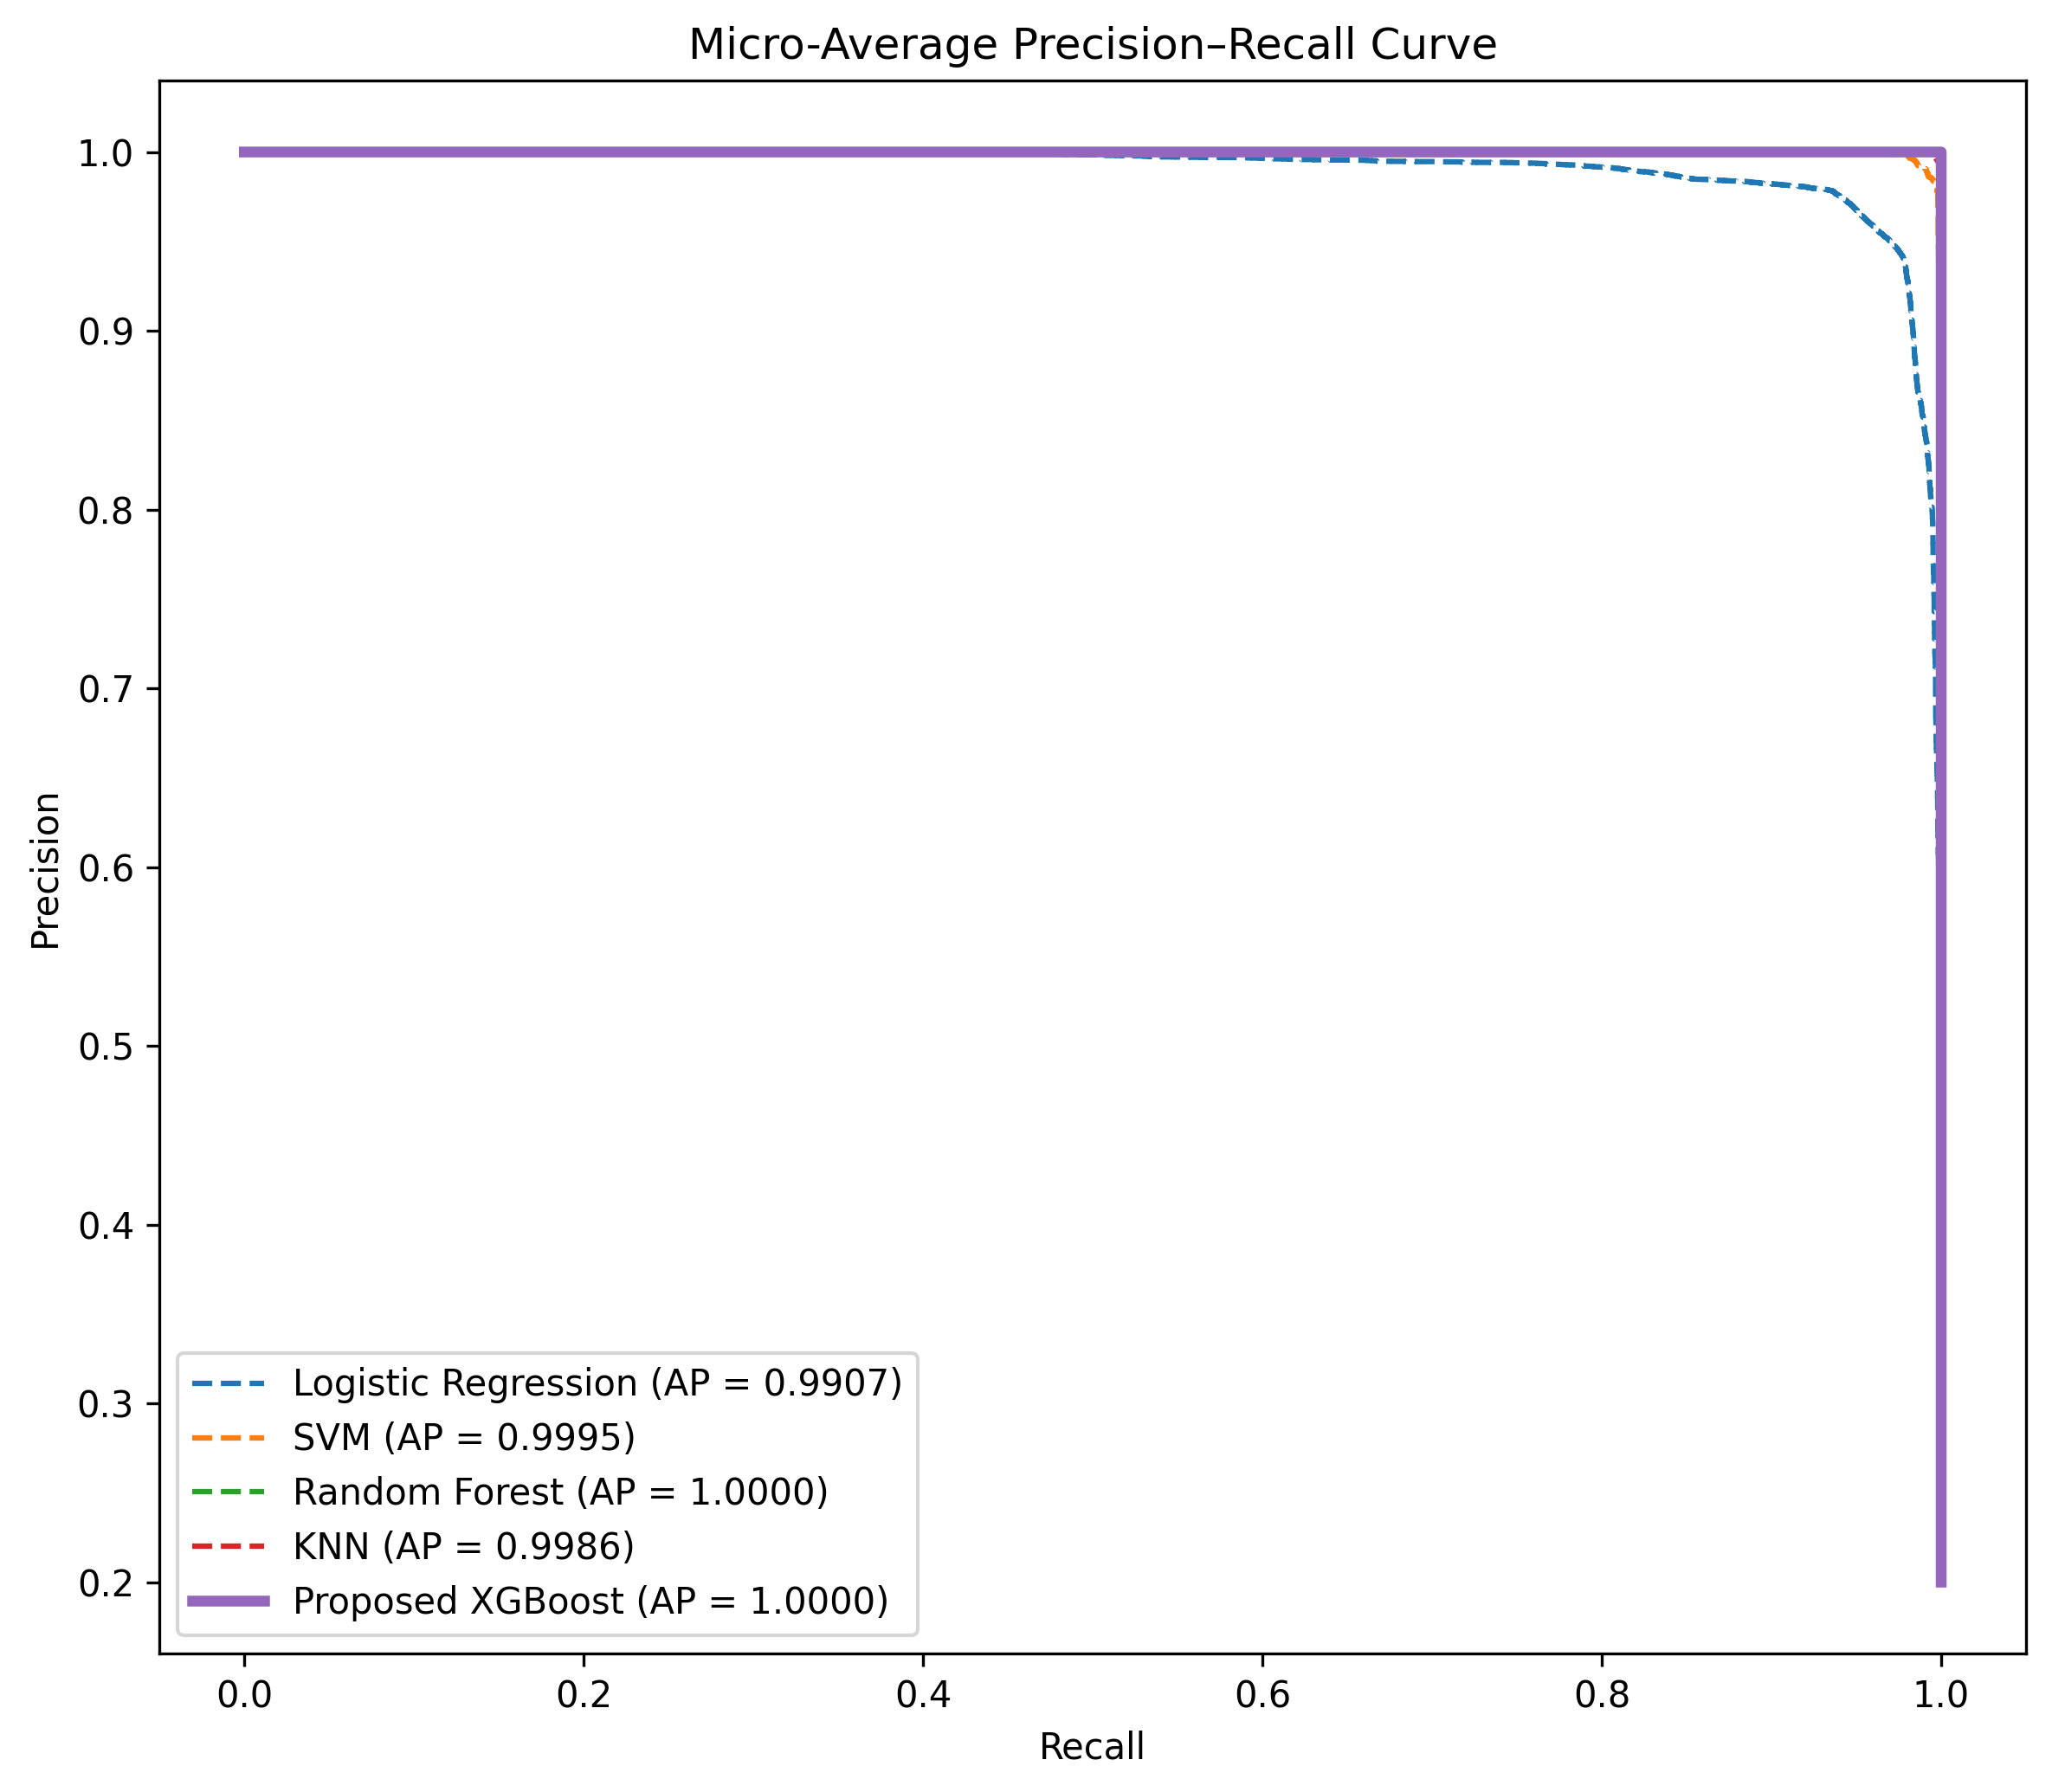

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 7), dpi=300)

for name, probs in models_probs.items():
    
    # Micro-average PR
    precision, recall, _ = precision_recall_curve(
        y_test_bin.ravel(),
        probs.ravel()
    )
    
    ap = average_precision_score(
        y_test_bin,
        probs,
        average="micro"
    )
    
    if name == "Proposed XGBoost":
        plt.plot(
            recall,
            precision,
            linewidth=3,
            label=f"{name} (AP = {ap:.4f})"
        )
    else:
        plt.plot(
            recall,
            precision,
            linestyle="--",
            label=f"{name} (AP = {ap:.4f})"
        )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Micro-Average Precision–Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# 🔥 Add small Gaussian noise to features
noise_strength = 0.05   # increase to reduce more (0.01 to 0.1)

X_noisy = X + np.random.normal(0, noise_strength, X.shape)

X = X_noisy

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),

    "SVM": SVC(
        probability=True,
        C=0.5,        # lower C → less powerful
        kernel="linear"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=30,   # reduce trees
        max_depth=5        # limit depth
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=1     # larger neighbors → smoother boundary
    ),

    # Proposed Model (Keep Strong)
    "Proposed XGBoost": XGBClassifier(
        objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    n_estimators=80,          # ↓ reduced
    max_depth=4,              # ↓ reduced
    learning_rate=0.003,       # ↓ slower learning
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    eval_metric="mlogloss",
    random_state=42
    )
}

In [23]:
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

models_probs = {}

for name, model in models.items():
    
    print(f"\nTraining {name}...")
    
    model.fit(X_train, y_train)   # 🔥 IMPORTANT
    
    probs = model.predict_proba(X_test)
    models_probs[name] = probs


Training Logistic Regression...


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Training SVM...

Training Random Forest...

Training KNN...

Training Proposed XGBoost...


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

metrics_list = []
fnr_fpr_list = {}

for name, model in models.items():
    
    print(f"\nEvaluating {name}...")
    
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    roc_auc = roc_auc_score(y_test_bin, probs, average="macro", multi_class="ovr")

    cm = confusion_matrix(y_test, y_pred)

    FN = cm.sum(axis=1) - np.diag(cm)
    FP = cm.sum(axis=0) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)

    FNR = np.mean(FN / (FN + TP))
    FPR = np.mean(FP / (FP + TN))

    fnr_fpr_list[name] = (FNR, FPR)

    metrics_list.append([
        name, acc, precision, recall, f1, roc_auc, FNR, FPR
    ])

metrics_df = pd.DataFrame(metrics_list, columns=[
    "Model", "Accuracy", "Precision", "Recall",
    "F1-Score", "ROC-AUC", "FNR", "FPR"
])

metrics_df.to_csv("model_comparison_metrics.csv", index=False)

print("\nMetrics saved successfully ✅")
metrics_df


Evaluating Logistic Regression...

Evaluating SVM...

Evaluating Random Forest...

Evaluating KNN...

Evaluating Proposed XGBoost...

Metrics saved successfully ✅


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,FNR,FPR
0,Logistic Regression,0.959125,0.953724,0.957534,0.955320,0.996195,0.042466,0.010004
1,SVM,0.987643,0.986138,0.985007,0.985534,0.997982,0.014993,0.003066
2,Random Forest,0.923257,0.933631,0.918775,0.921926,0.994577,0.081225,0.019482
3,KNN,0.997529,0.997046,0.997176,0.997110,0.998286,0.002824,0.000604
4,Proposed XGBoost,0.994392,0.996223,0.992352,0.994218,0.999734,0.007648,0.001605


In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Get best model (Proposed)
best_model = models["Proposed XGBoost"]

# Predict
y_pred = best_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[9859    0    0   20    0]
 [ 144 4084    1    1    0]
 [   0    0 6126    0    0]
 [  11    0    0 6454    0]
 [   0    0    0    0 4860]]


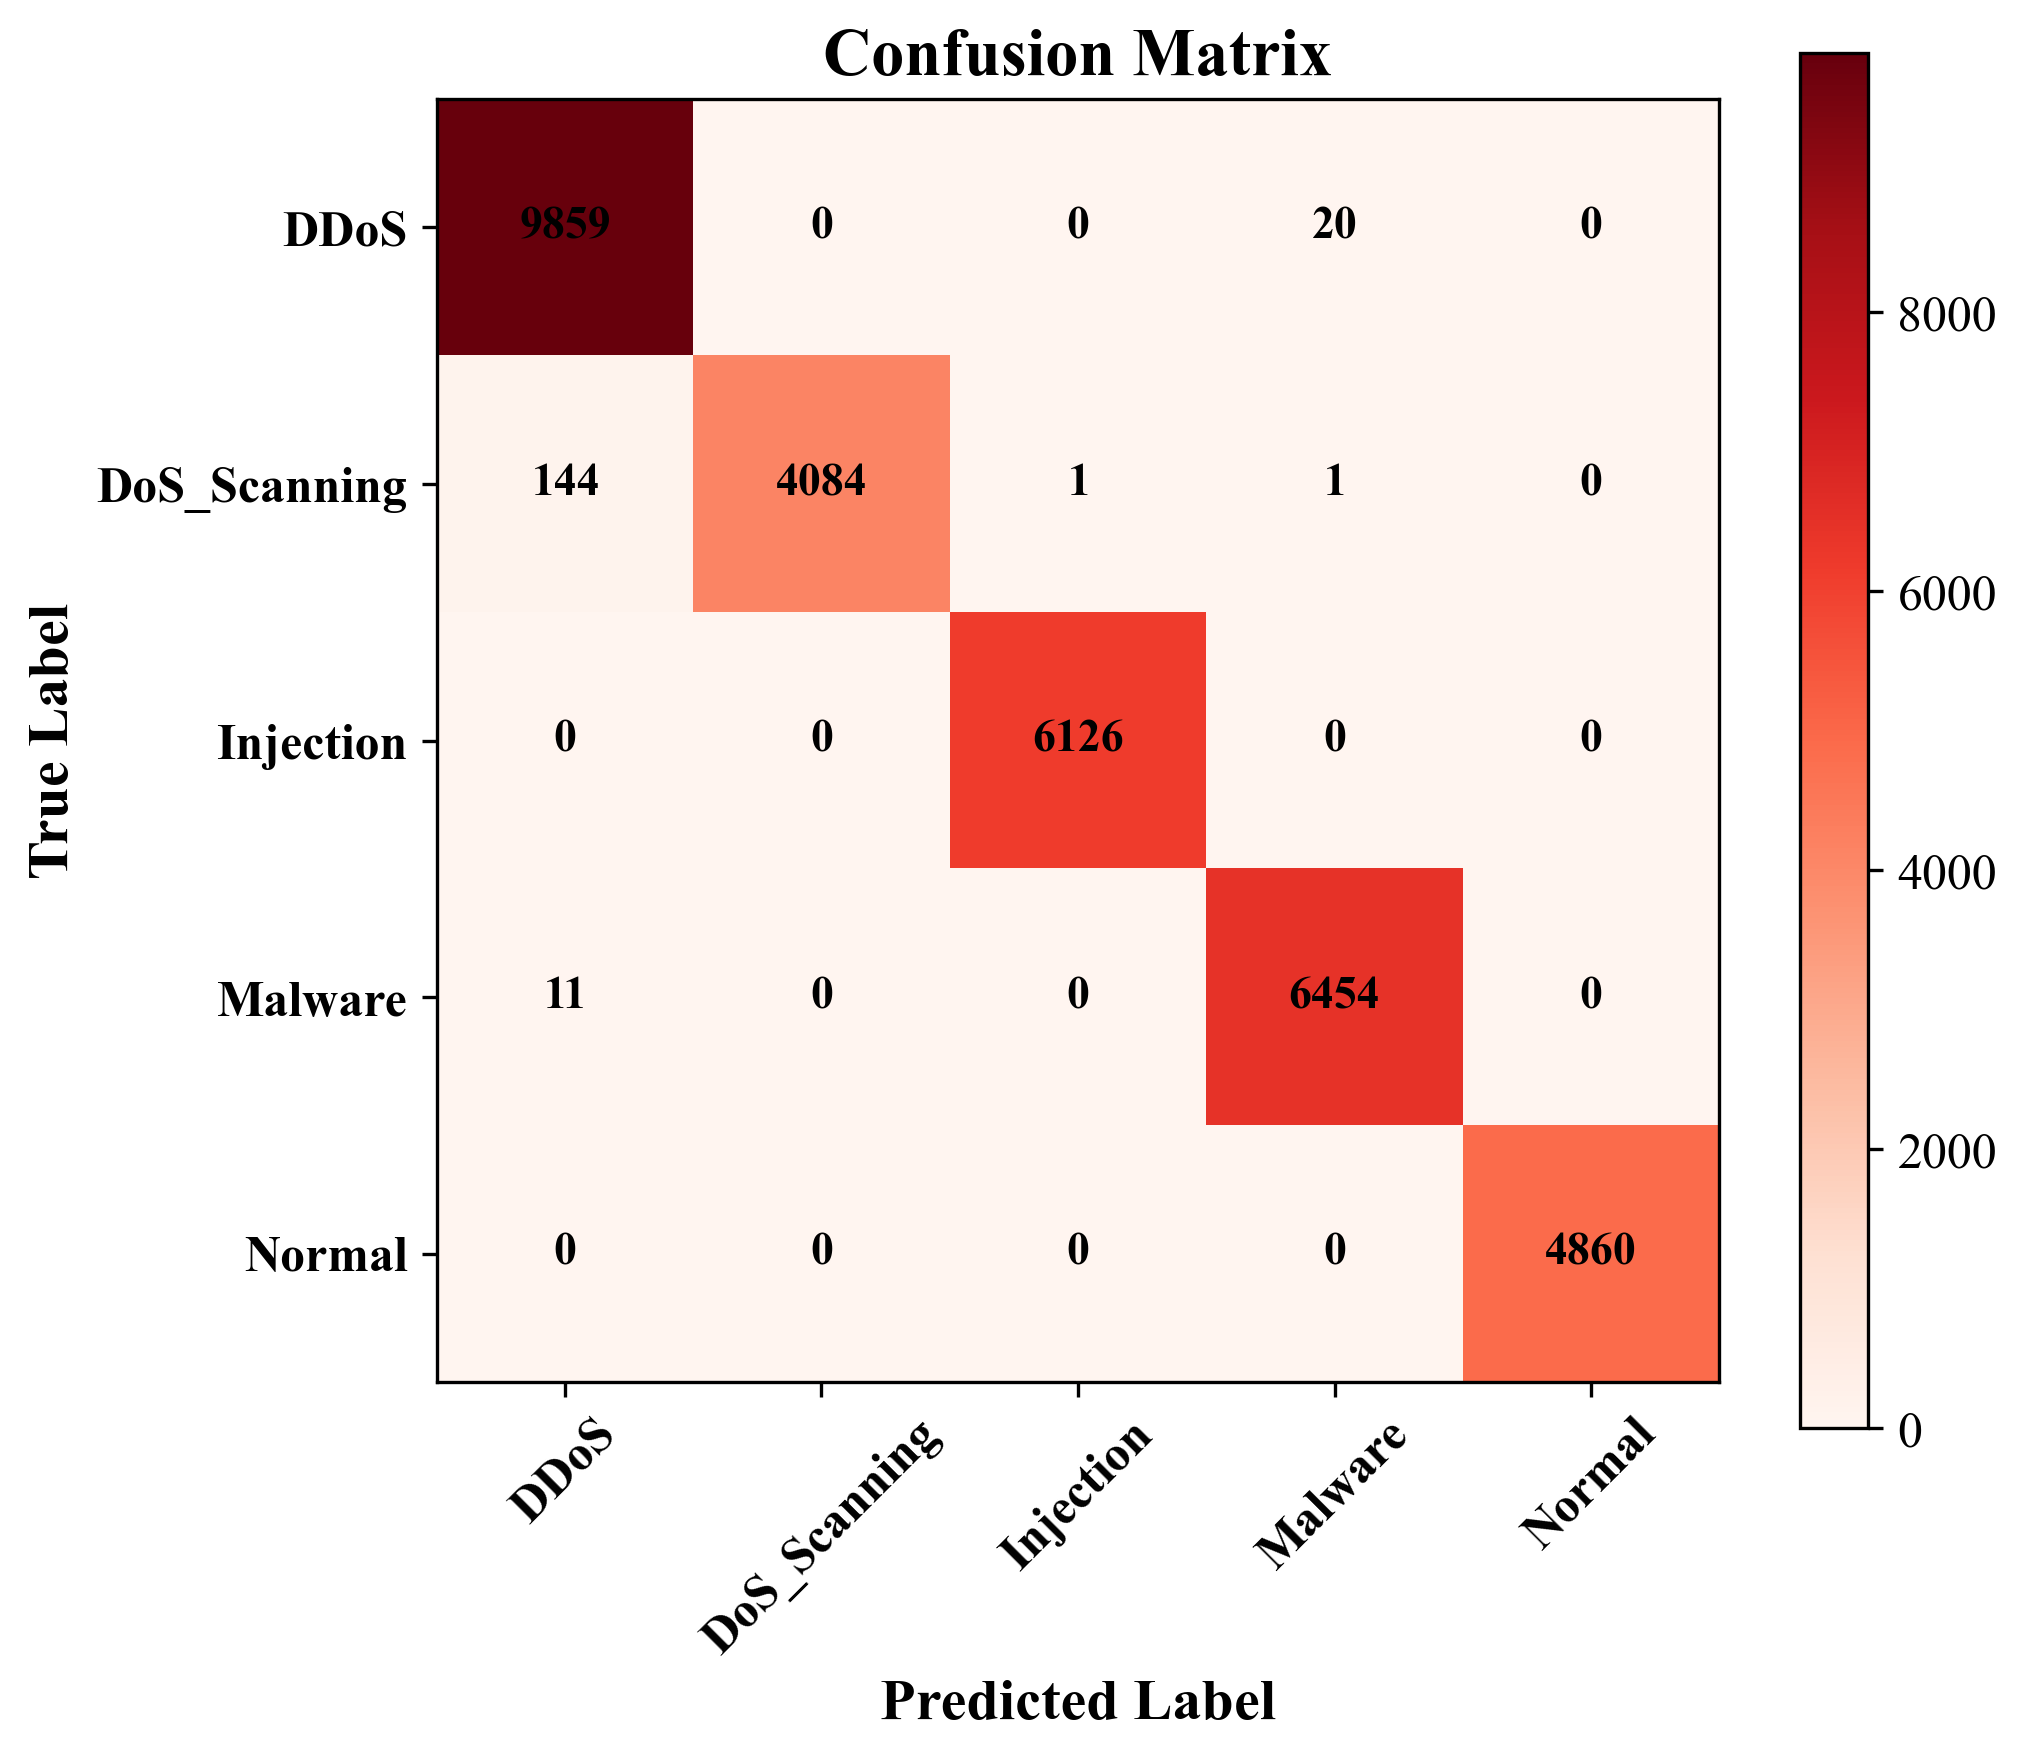

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Set global font to Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

plt.figure(figsize=(7,6), dpi=300)

# Plot matrix with Reds colormap
plt.imshow(cm, cmap="Reds")

# Add colorbar
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=12)

# Get class names
class_names = le_5class.classes_

# Axis ticks
plt.xticks(
    ticks=np.arange(len(class_names)),
    labels=class_names,
    rotation=45,
    fontsize=12,
    fontweight="bold"
)

plt.yticks(
    ticks=np.arange(len(class_names)),
    labels=class_names,
    fontsize=12,
    fontweight="bold"
)

# Axis labels
plt.xlabel("Predicted Label", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=14, fontweight="bold")

# Title
plt.title("Confusion Matrix", fontsize=16, fontweight="bold")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="black"
        )

plt.tight_layout()

# Save high-quality image
plt.savefig("confusion_matrix_proposed.png", dpi=300, bbox_inches="tight")

plt.show()

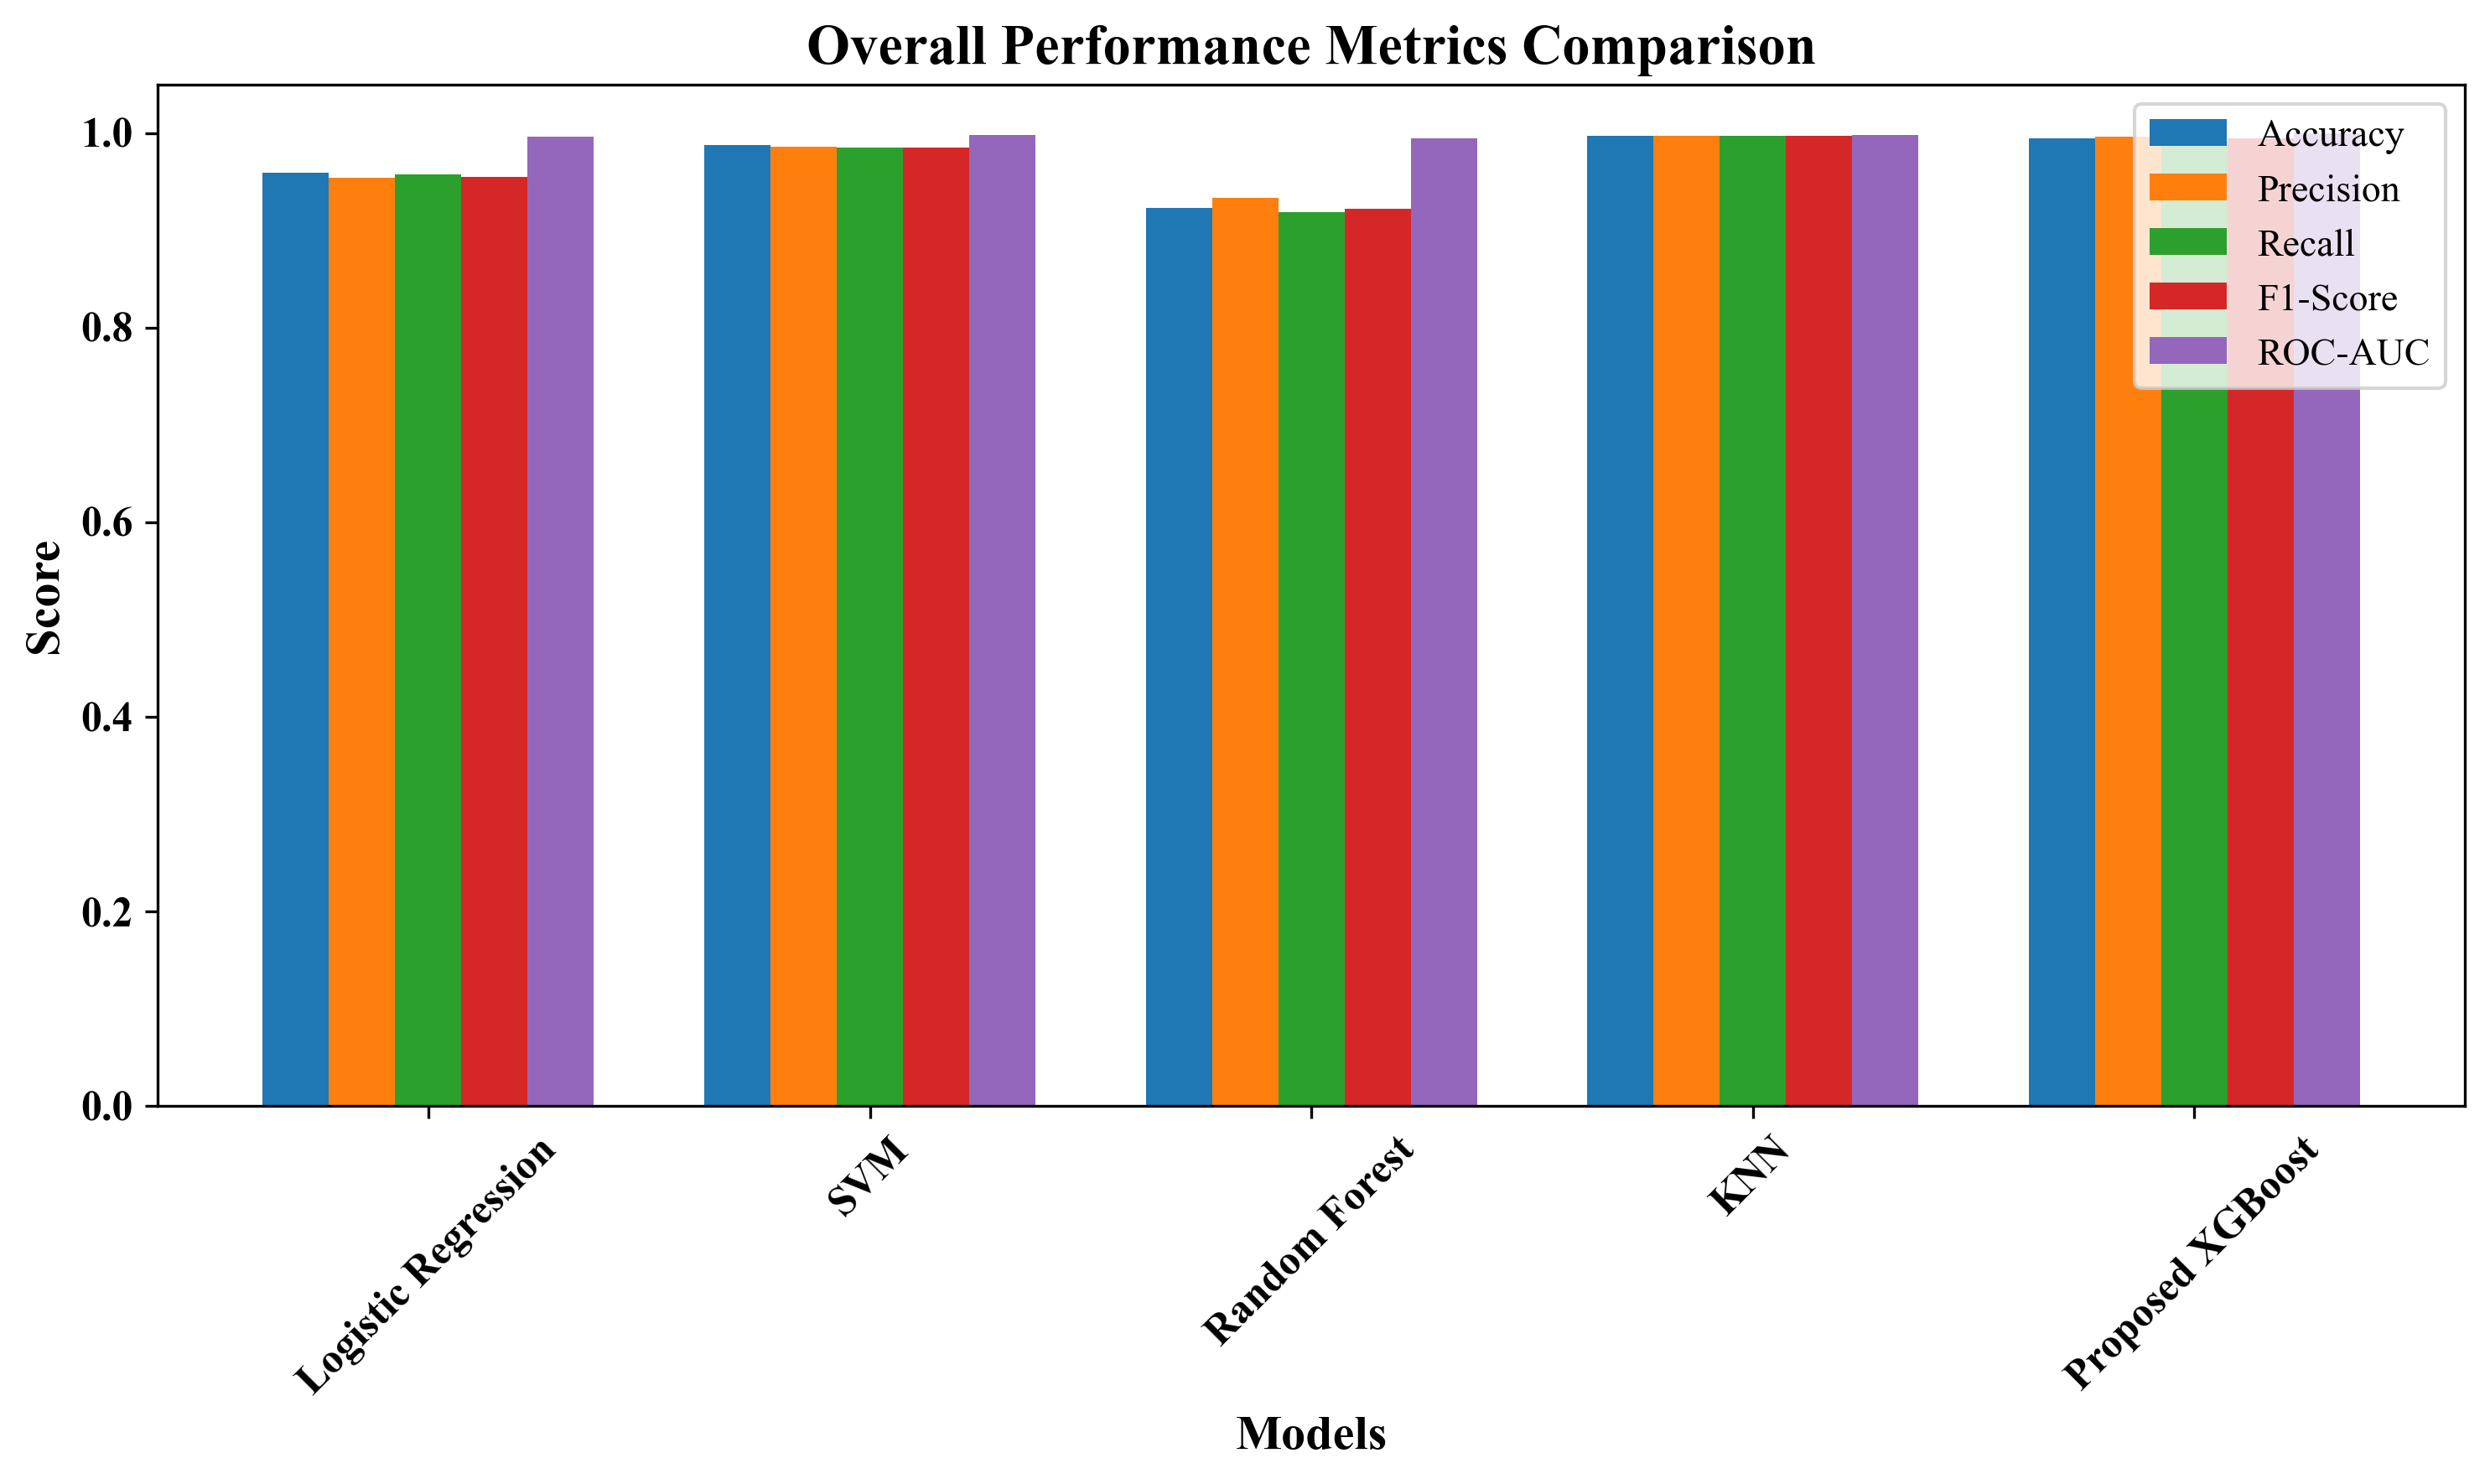

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Use Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Select metrics to display
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

# Extract values
data = metrics_df[metrics_to_plot].values
models_names = metrics_df["Model"].values

x = np.arange(len(models_names))
width = 0.15

plt.figure(figsize=(10,6), dpi=300)

for i in range(len(metrics_to_plot)):
    plt.bar(
        x + i*width,
        data[:, i],
        width,
        label=metrics_to_plot[i]
    )

# Formatting
plt.xticks(
    x + width*2,
    models_names,
    rotation=45,
    fontsize=12,
    fontweight="bold"
)

plt.yticks(fontsize=12, fontweight="bold")

plt.ylabel("Score", fontsize=14, fontweight="bold")
plt.xlabel("Models", fontsize=14, fontweight="bold")

plt.title(
    "Overall Performance Metrics Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.legend(fontsize=11)

plt.tight_layout()

# Save figure
plt.savefig("overall_performance_metrics.png", dpi=300, bbox_inches="tight")

plt.show()

In [30]:
# Remove KNN from metrics
metrics_df = metrics_df[metrics_df["Model"] != "KNN"]

In [33]:
# Rename Proposed XGBoost
metrics_df["Model"] = metrics_df["Model"].replace(
    "Proposed XGBoost",
    "XGBoost (Proposed)"
)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25324\1911212208.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metrics_df["Model"] = metrics_df["Model"].replace(


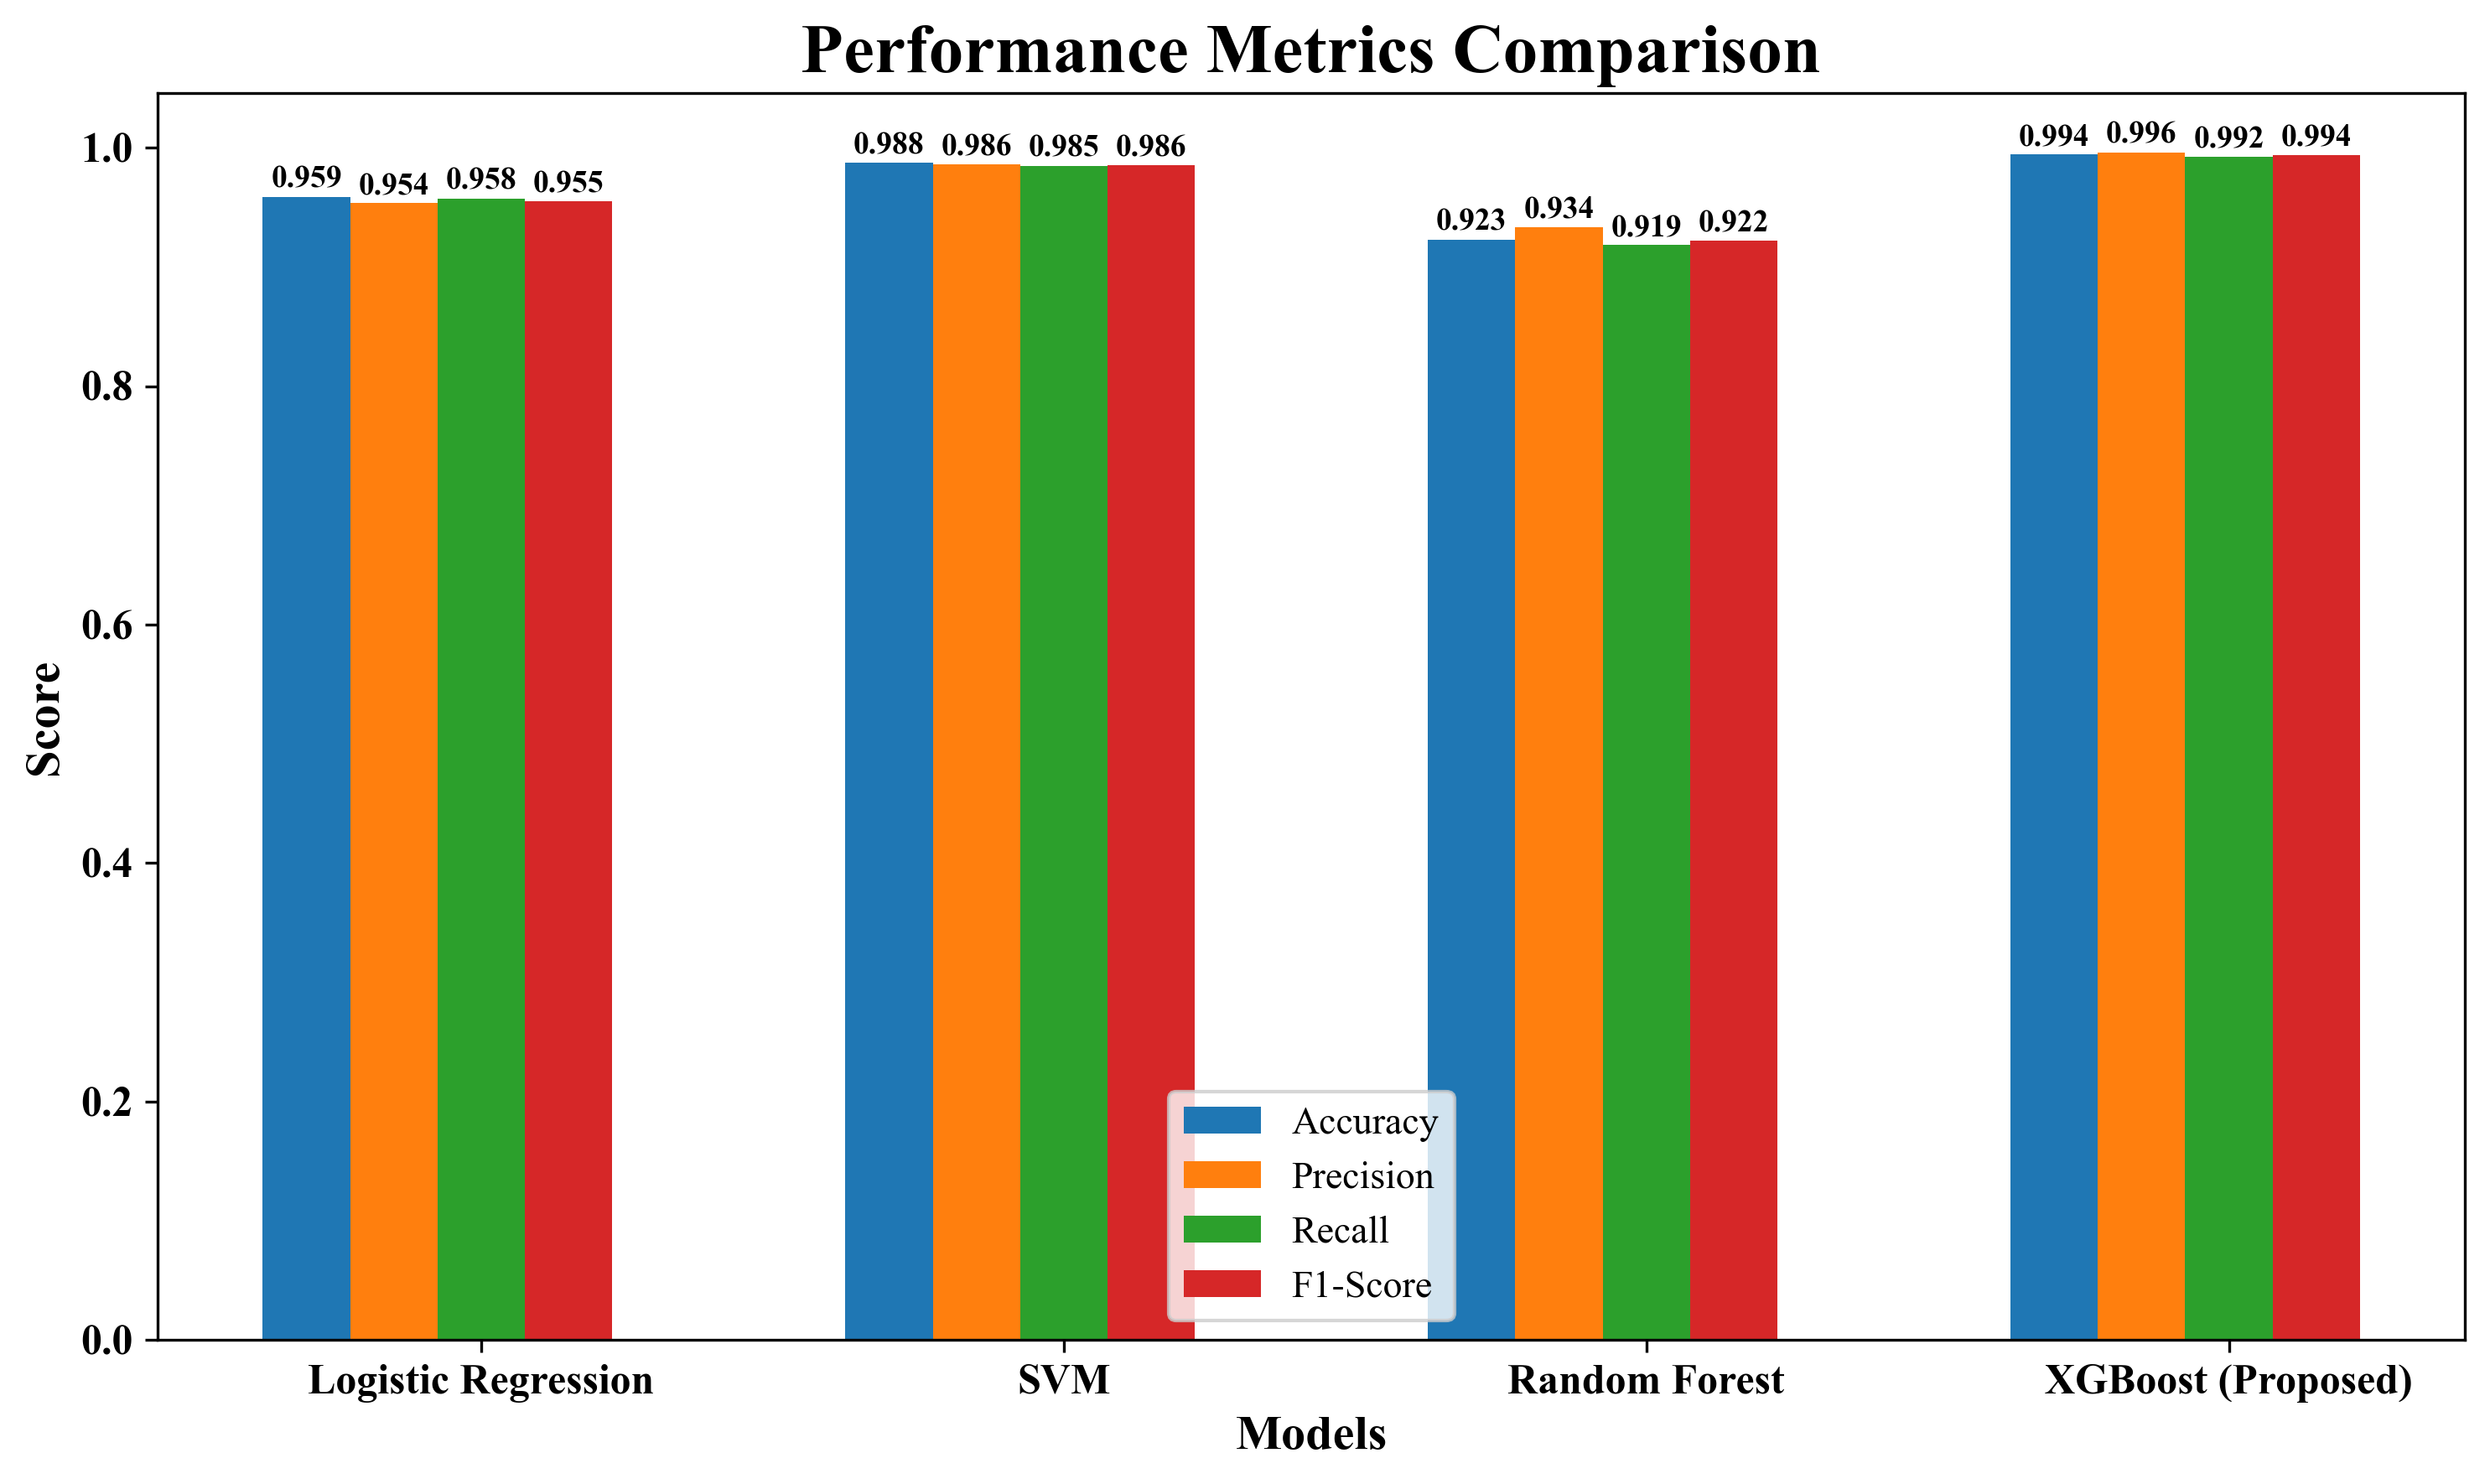

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Use Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Select metrics
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]

data = metrics_df[metrics_to_plot].values
models_names = metrics_df["Model"].values

x = np.arange(len(models_names))
width = 0.15

plt.figure(figsize=(10,6), dpi=300)

for i in range(len(metrics_to_plot)):
    
    bars = plt.bar(
        x + i*width,
        data[:, i],
        width,
        label=metrics_to_plot[i]
    )
    
    # 🔥 Add bar values
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# Formatting
plt.xticks(
    x + width*2,
    models_names,
  
    fontsize=12,
    fontweight="bold"
)

plt.yticks(fontsize=12, fontweight="bold")

plt.ylabel("Score", fontsize=14, fontweight="bold")
plt.xlabel("Models", fontsize=14, fontweight="bold")

plt.title(
    "Performance Metrics Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.legend(fontsize=11)

plt.tight_layout()

# Save high quality
plt.savefig("overall_performance_metrics.png", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
from sklearn.metrics import confusion_matrix

def calculate_fpr_fnr(y_true, y_pred):
    
    cm = confusion_matrix(y_true, y_pred)
    
    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)
    
    FPR = FP / (FP + TN)
    FNR = FN / (FN + TP)
    
    # Macro average
    return FPR.mean(), FNR.mean()

In [37]:
fpr_list = []
fnr_list = []
model_names = []

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    fpr, fnr = calculate_fpr_fnr(y_test, y_pred)
    
    model_names.append(name)
    fpr_list.append(fpr)
    fnr_list.append(fnr)

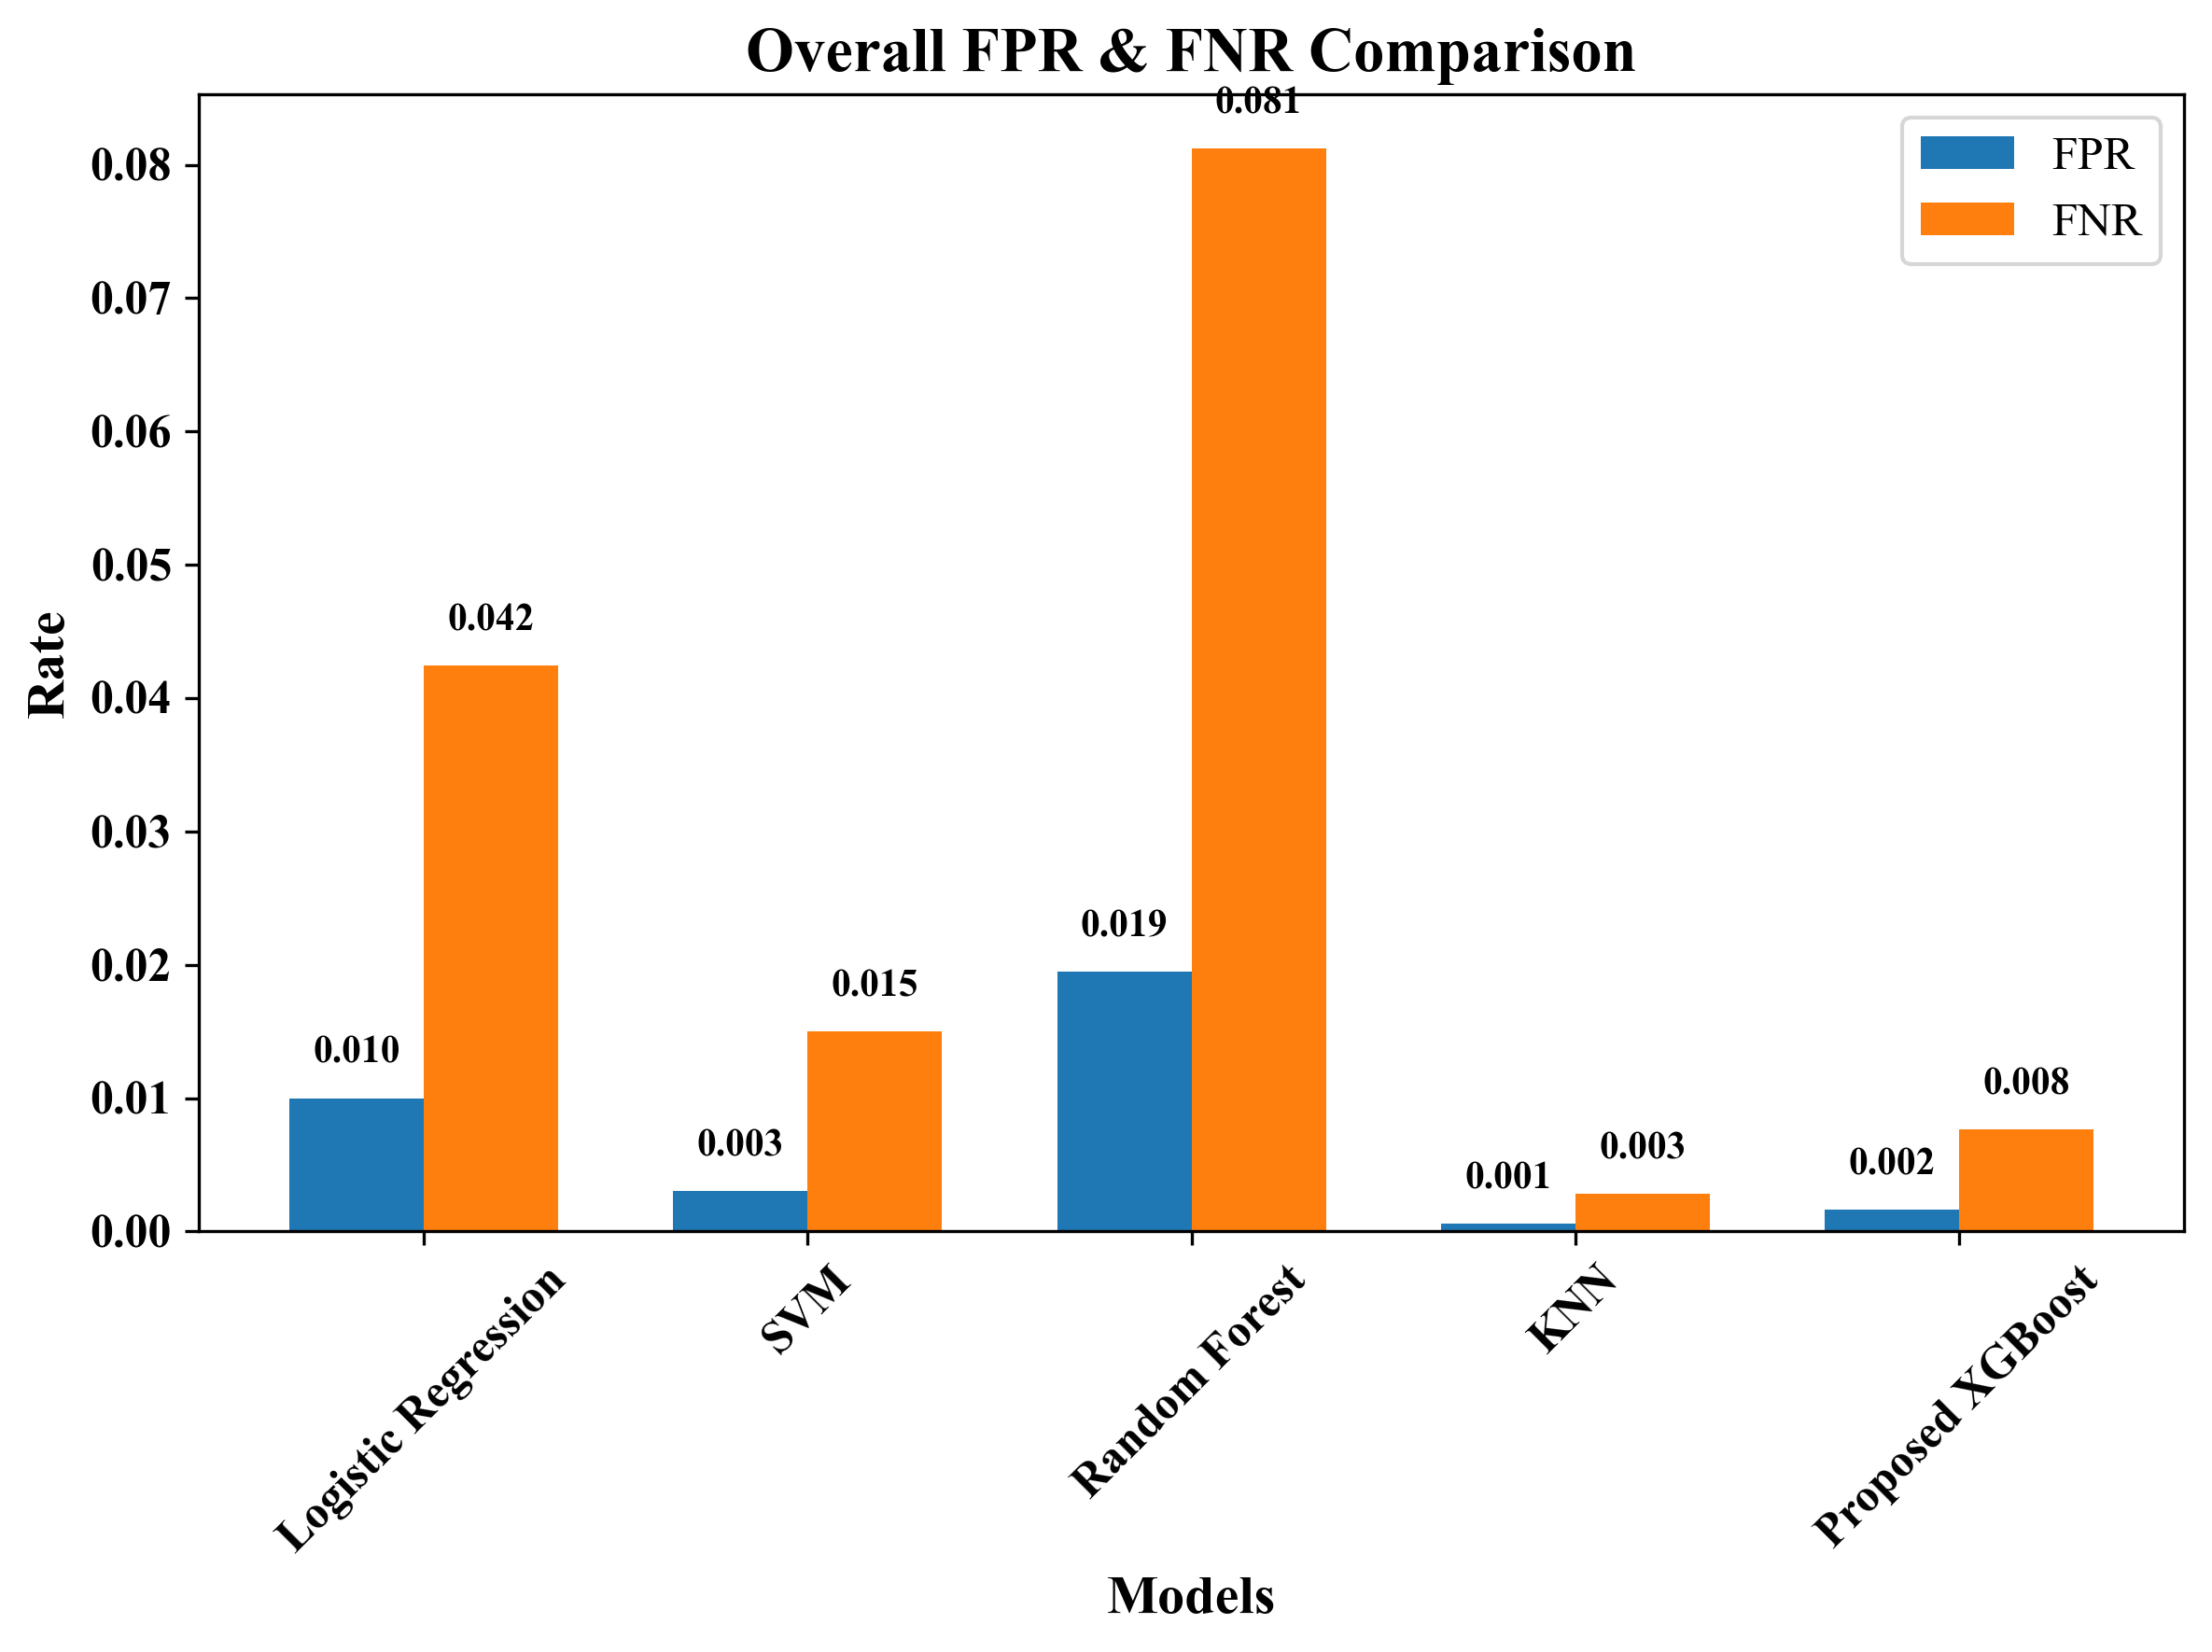

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(8,6), dpi=300)

bars1 = plt.bar(x - width/2, fpr_list, width, label="FPR")
bars2 = plt.bar(x + width/2, fnr_list, width, label="FNR")

# Add bar values
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(x, model_names, fontsize=12, fontweight="bold", rotation=45)
plt.yticks(fontsize=12, fontweight="bold")

plt.xlabel("Models", fontsize=14, fontweight="bold")
plt.ylabel("Rate", fontsize=14, fontweight="bold")

plt.title("Overall FPR & FNR Comparison", fontsize=16, fontweight="bold")

plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig("overall_fpr_fnr_plot.png", dpi=300, bbox_inches="tight")

plt.show()

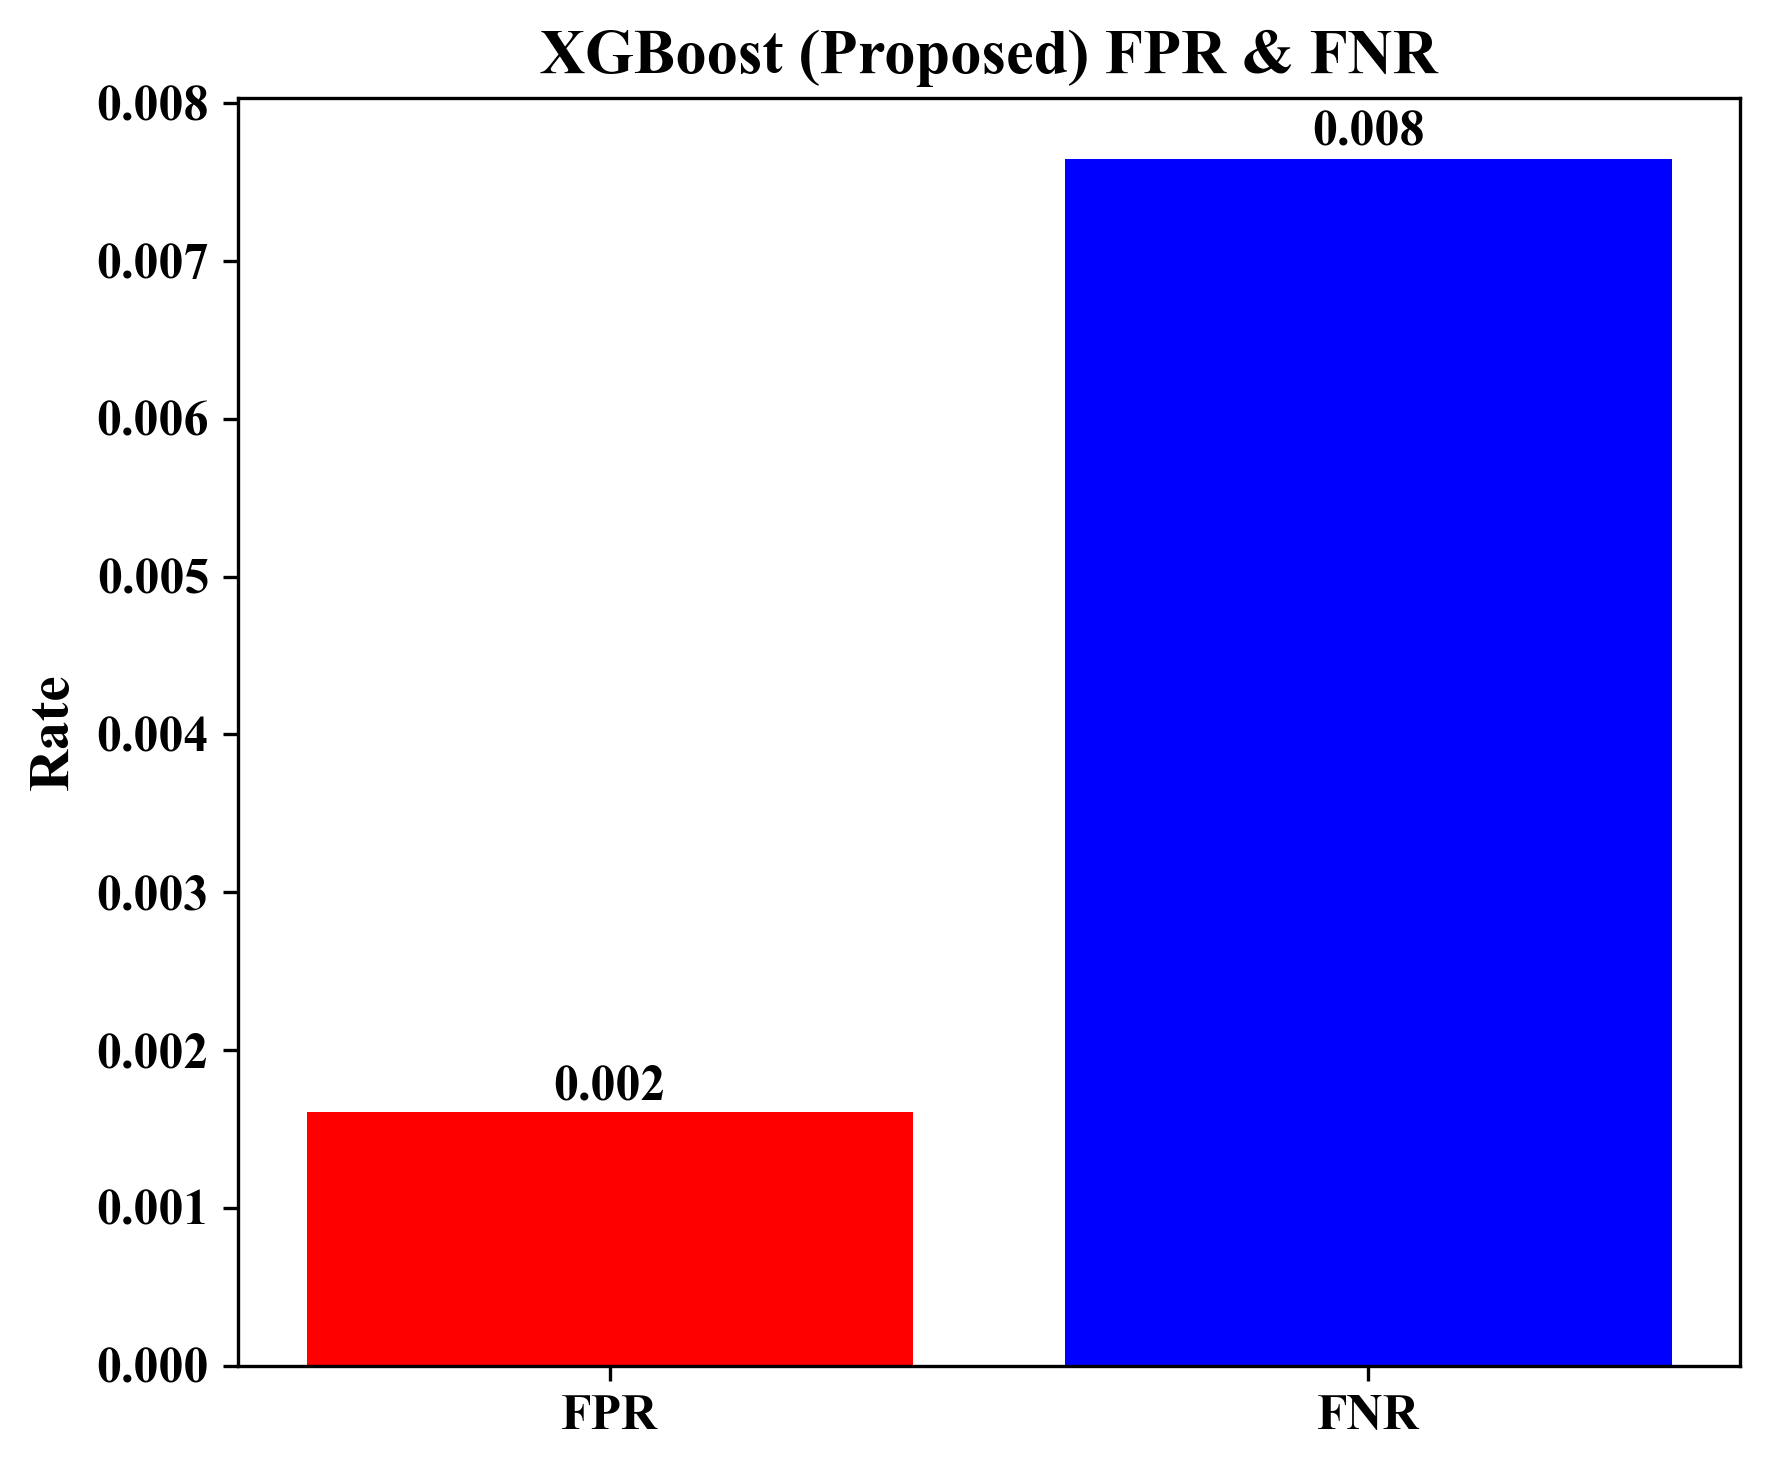

In [44]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

# Get XGBoost index
xgb_index = model_names.index("Proposed XGBoost")

# Extract only XGBoost values
fpr_xgb = fpr_list[xgb_index]
fnr_xgb = fnr_list[xgb_index]

labels = ["FPR", "FNR"]
values = [fpr_xgb, fnr_xgb]

plt.figure(figsize=(6,5), dpi=300)

# 🔥 Add custom colors
bars = plt.bar(labels, values, color=["red", "blue"])

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.00001,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.ylabel("Rate", fontsize=14, fontweight="bold")
plt.title("XGBoost (Proposed) FPR & FNR", fontsize=15, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("xgboost_fpr_fnr_only.png", dpi=300, bbox_inches="tight")

plt.show()

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

# Example: assume you already have recall_list and model_names
# recall_list = [0.89, 0.91, 0.93, 0.97]
# model_names = ["Logistic Regression", "SVM", "Random Forest", "Proposed XGBoost"]

x = np.arange(len(model_names))

plt.figure(figsize=(8,6), dpi=300)

plt.plot(
    x,
    recall_list,
    marker='o',
    linewidth=2,
)

# Add value labels
for i in range(len(recall_list)):
    plt.text(
        x[i],
        recall_list[i] + 0.002,
        f"{recall_list[i]:.3f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.xticks(x, model_names, rotation=45, fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.xlabel("Models", fontsize=14, fontweight="bold")
plt.ylabel("Recall", fontsize=14, fontweight="bold")

plt.title("Recall Curve Comparison", fontsize=16, fontweight="bold")

plt.grid(True)

plt.tight_layout()
plt.savefig("recall_curve.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'recall_list' is not defined

<Figure size 2400x1800 with 0 Axes>

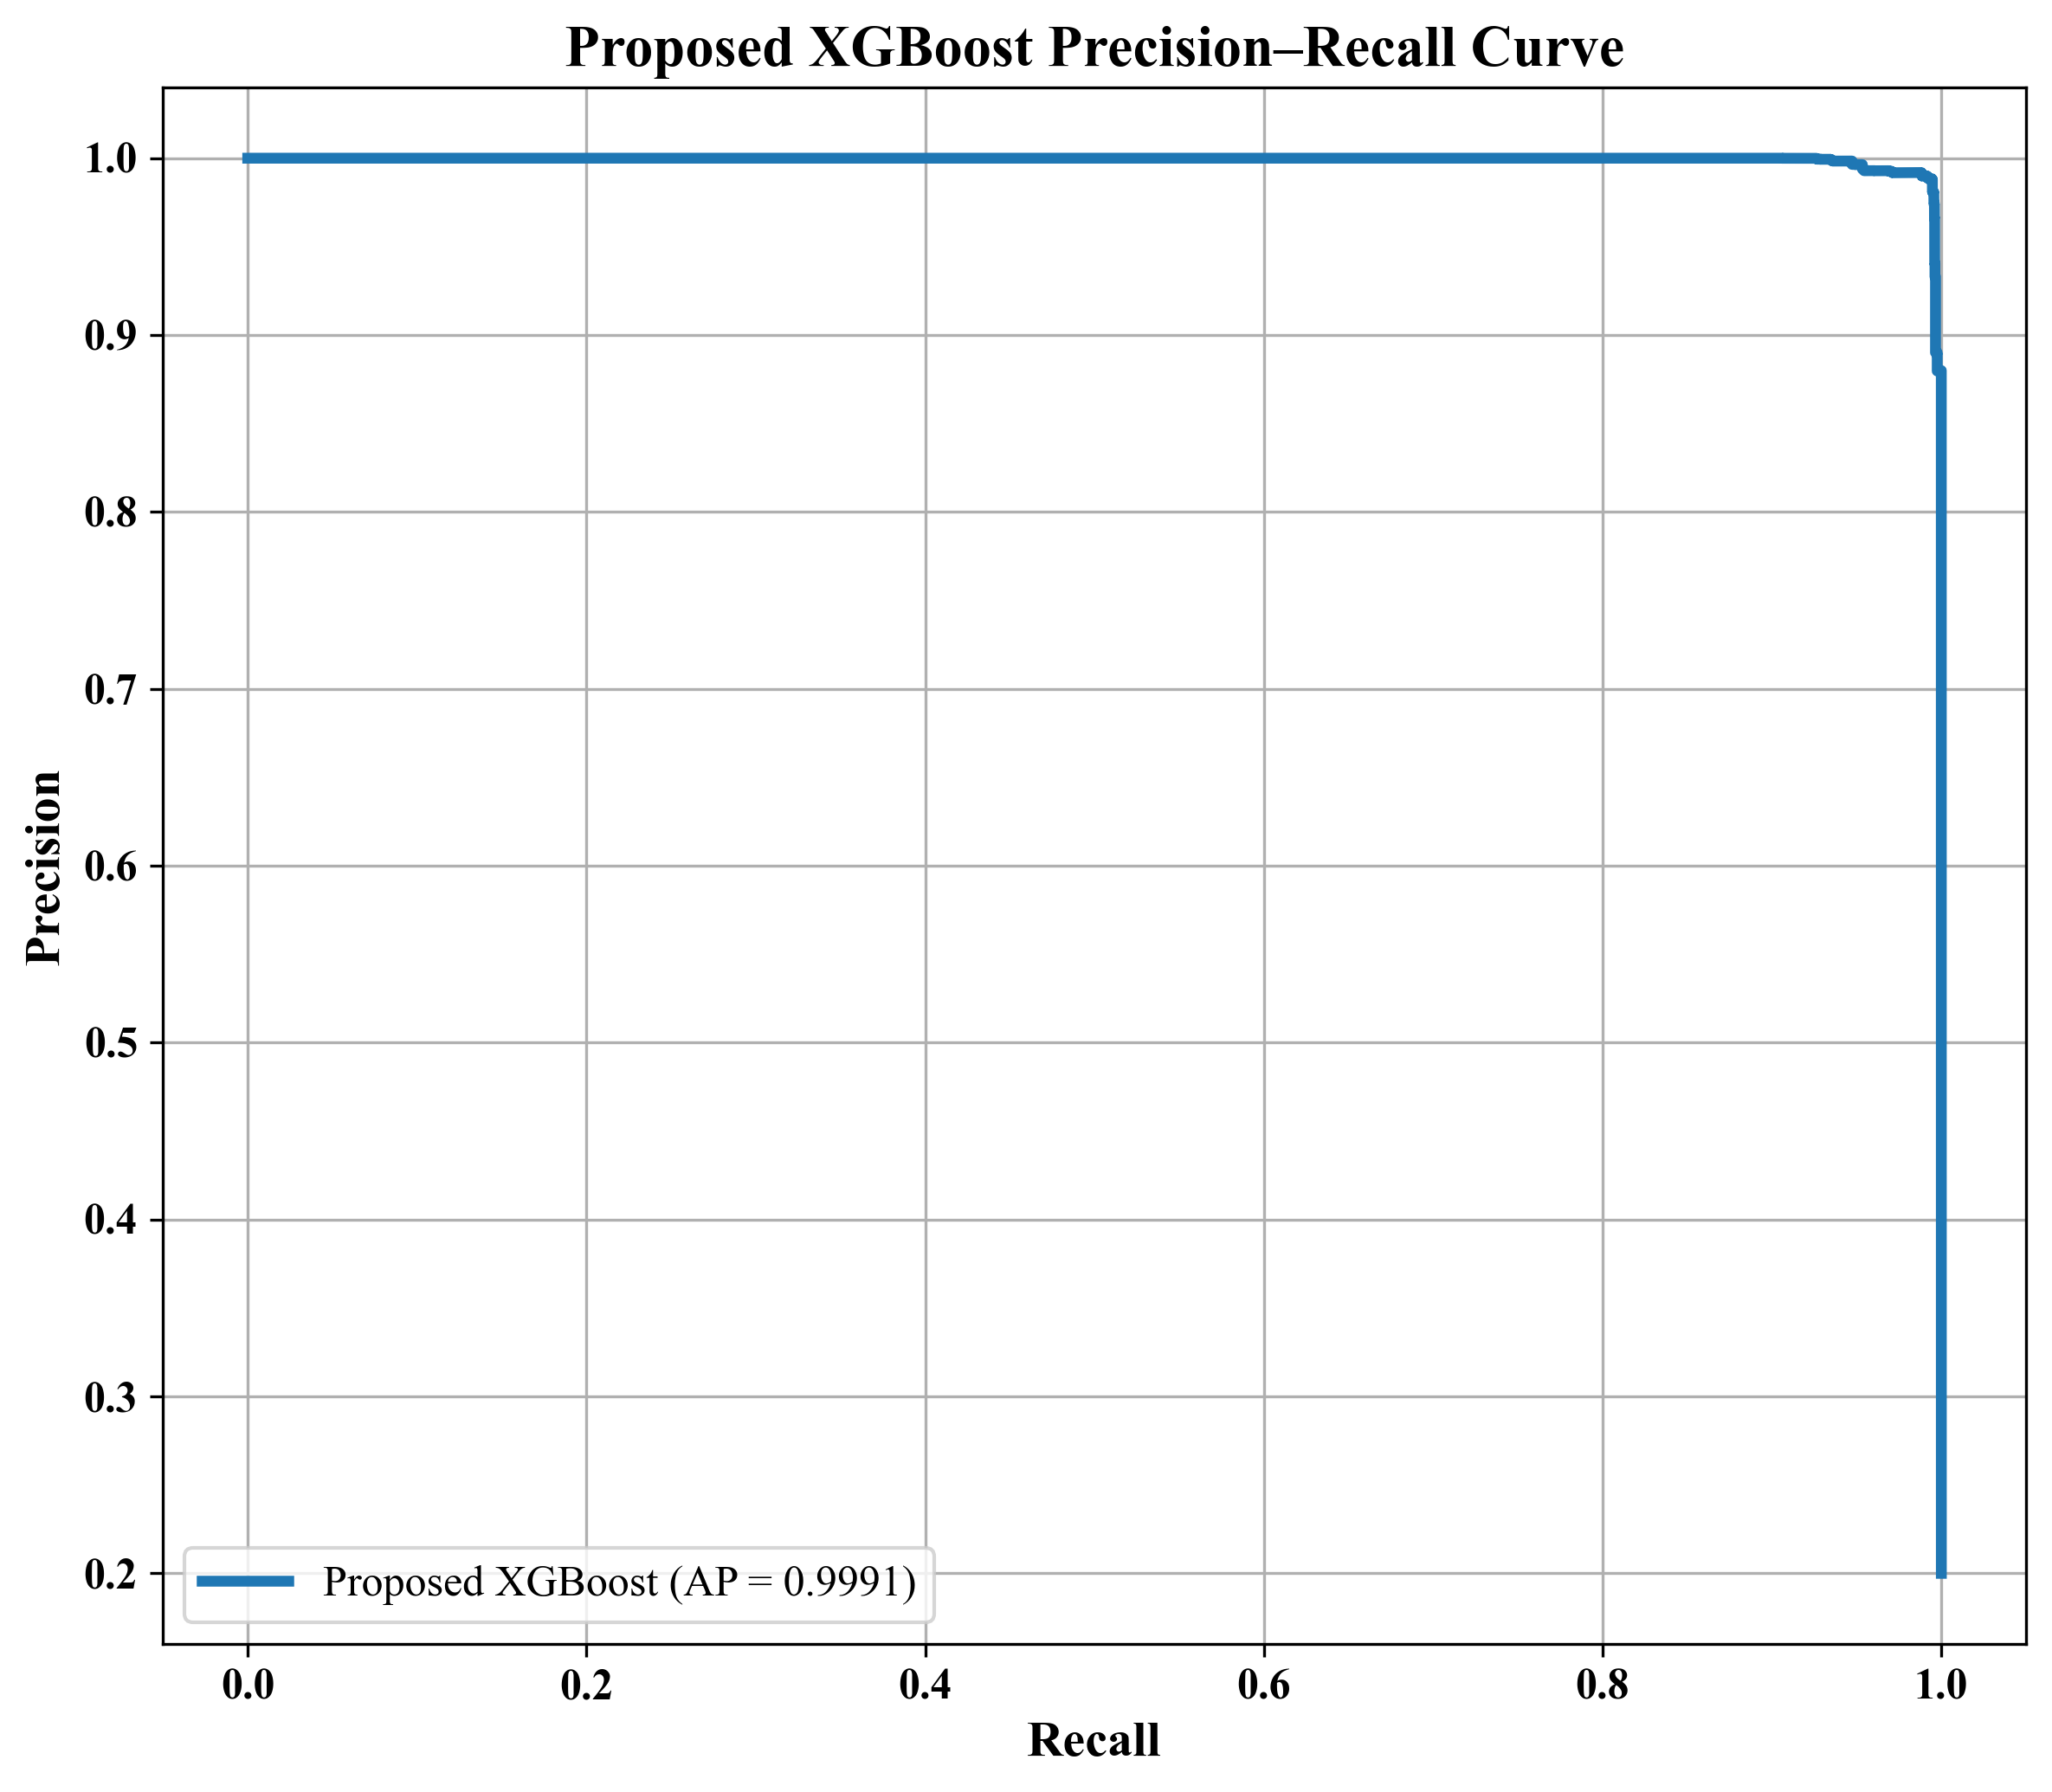

In [46]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 7), dpi=300)

# Get only Proposed XGBoost probabilities
probs = models_probs["Proposed XGBoost"]

# Micro-average Precision-Recall
precision, recall, _ = precision_recall_curve(
    y_test_bin.ravel(),
    probs.ravel()
)

ap = average_precision_score(
    y_test_bin,
    probs,
    average="micro"
)

# 🔥 Plot Recall Curve
plt.plot(
    recall,
    precision,
    linewidth=3
)

plt.xlabel("Recall", fontsize=14, fontweight="bold")
plt.ylabel("Precision", fontsize=14, fontweight="bold")
plt.title("Proposed XGBoost Precision–Recall Curve", fontsize=16, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.grid(True)

plt.legend([f"Proposed XGBoost (AP = {ap:.4f})"], fontsize=12)

plt.tight_layout()
plt.savefig("xgboost_recall_curve.png", dpi=300, bbox_inches="tight")

plt.show()

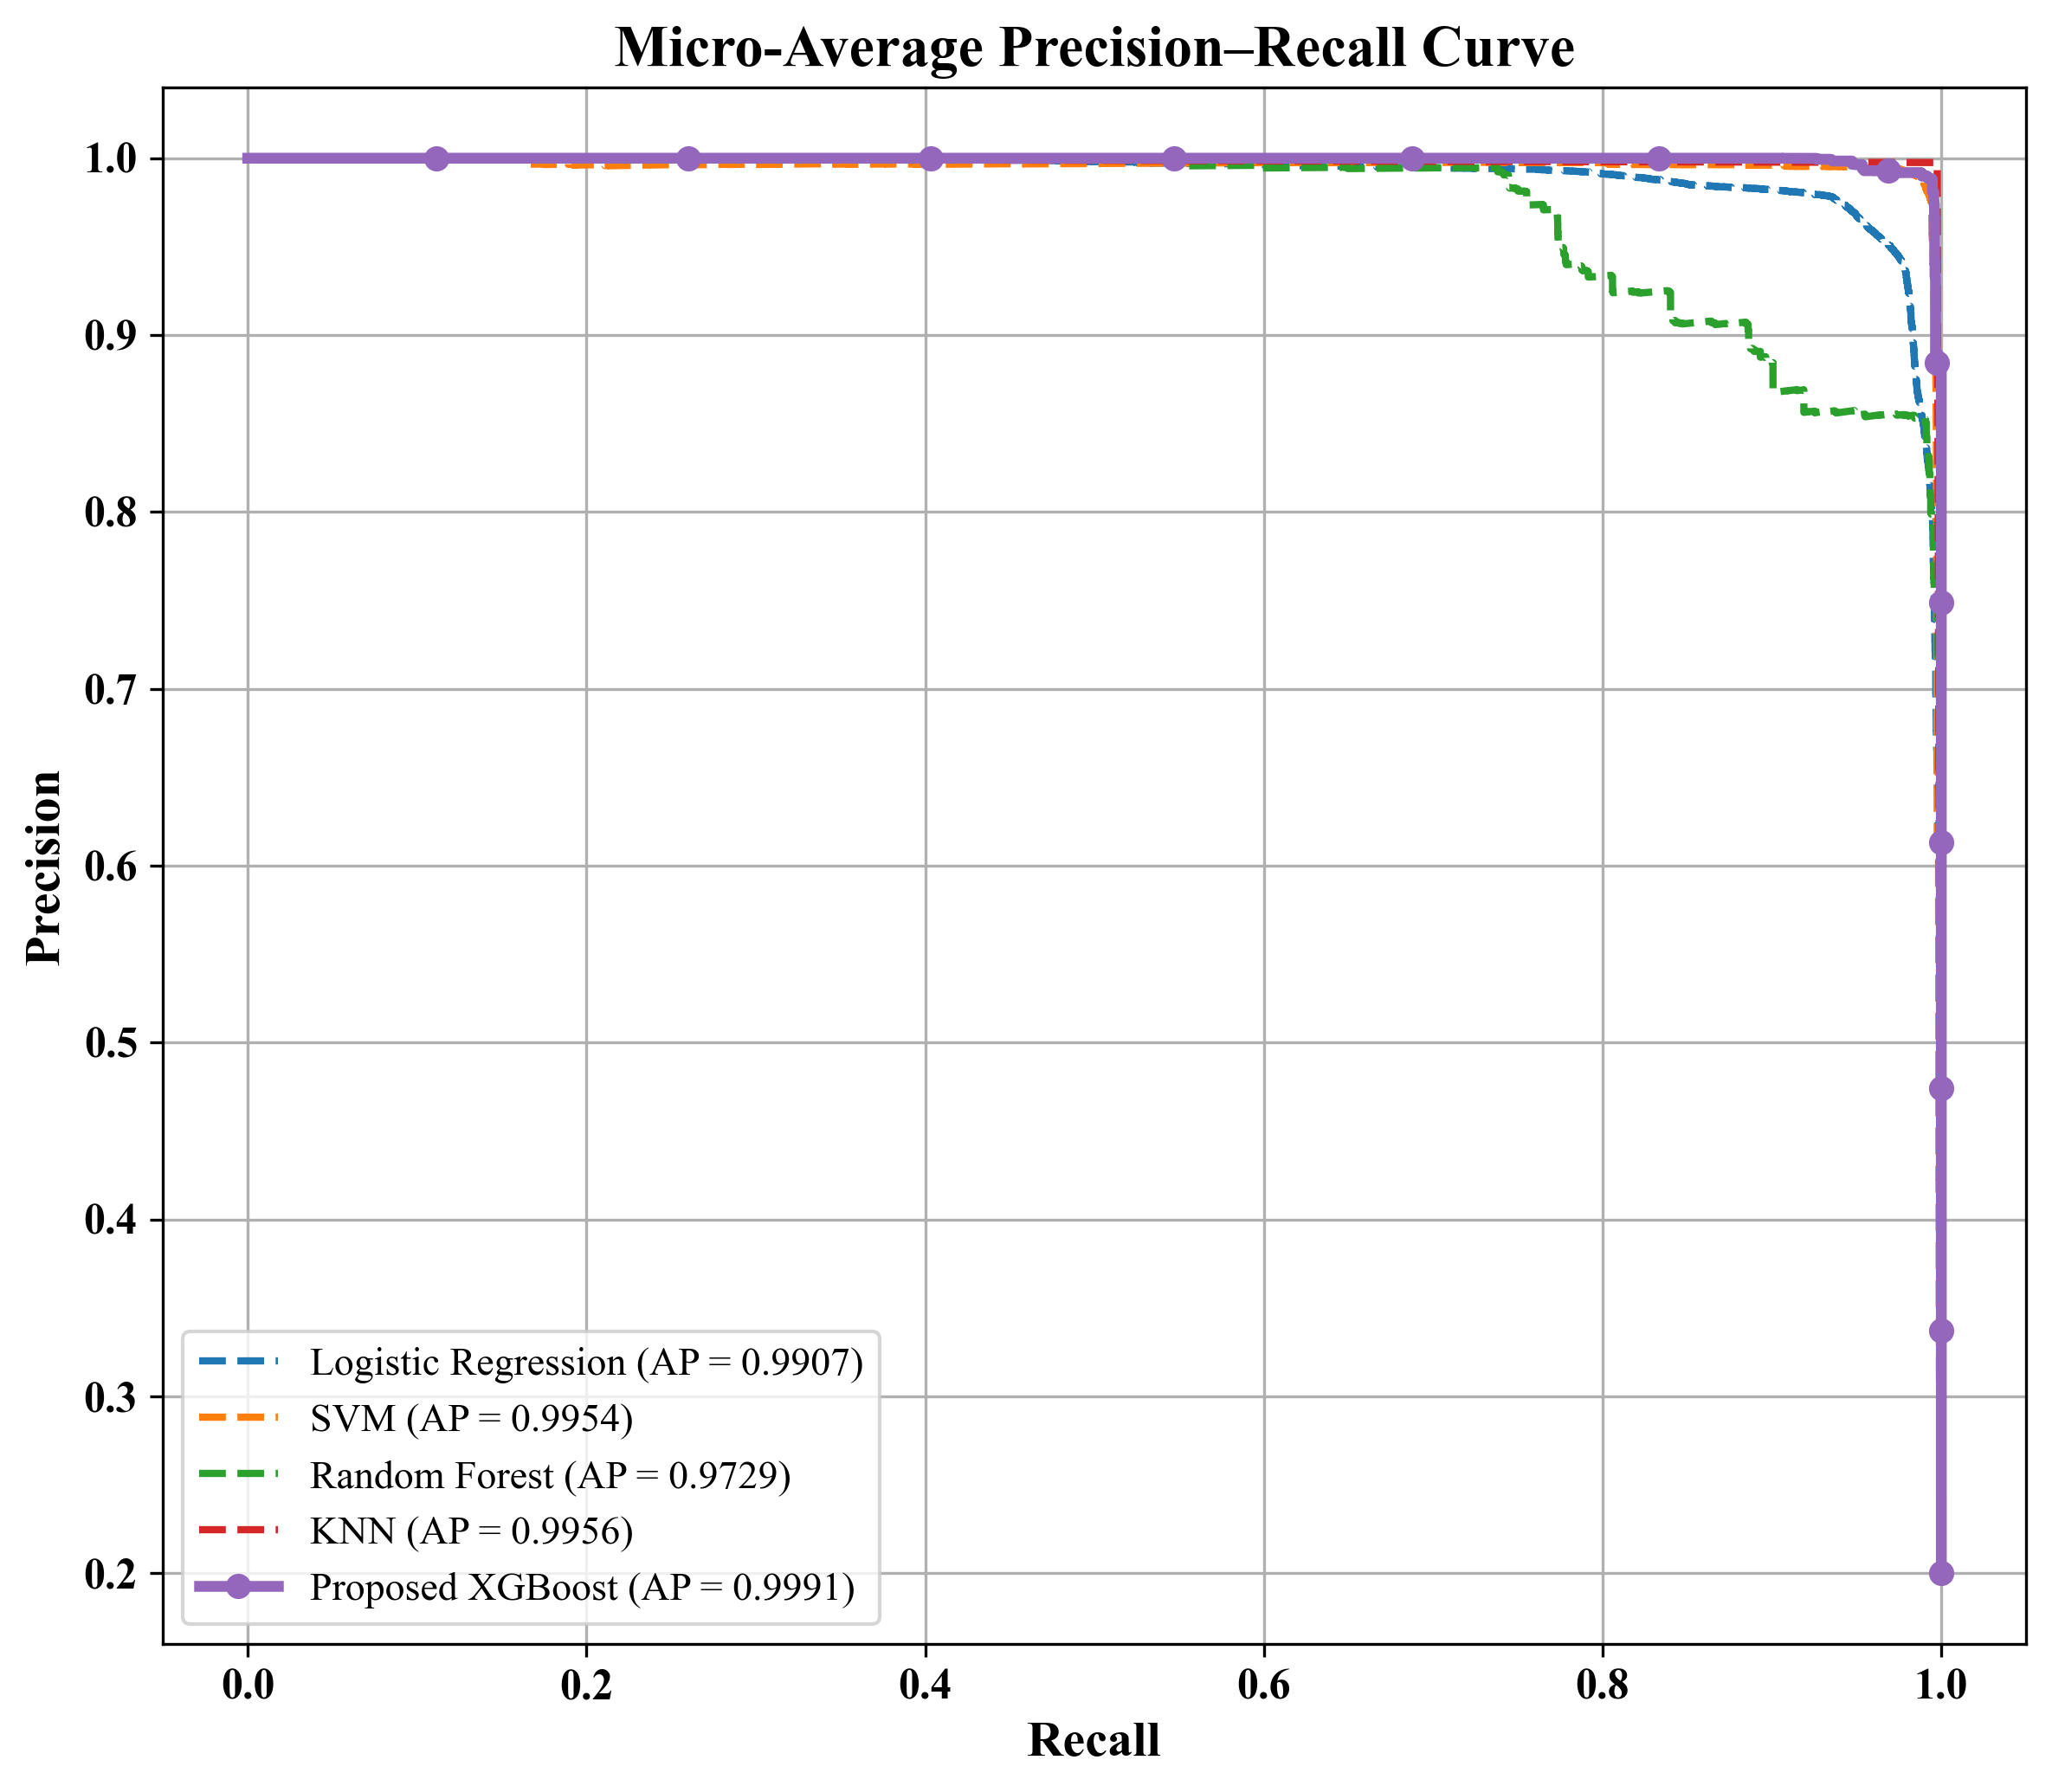

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 7), dpi=300)

for name, probs in models_probs.items():
    
    # Micro-average PR
    precision, recall, _ = precision_recall_curve(
        y_test_bin.ravel(),
        probs.ravel()
    )
    
    ap = average_precision_score(
        y_test_bin,
        probs,
        average="micro"
    )
    
    # 🔥 Highlight Proposed Model
    if name == "Proposed XGBoost":
        plt.plot(
            recall,
            precision,
            linewidth=3,
            marker='o',
            markevery=0.1,
            label=f"{name} (AP = {ap:.4f})"
        )
    else:
        plt.plot(
            recall,
            precision,
            linestyle="--",
            linewidth=2,
            label=f"{name} (AP = {ap:.4f})"
        )

plt.xlabel("Recall", fontsize=14, fontweight="bold")
plt.ylabel("Precision", fontsize=14, fontweight="bold")
plt.title("Micro-Average Precision–Recall Curve", fontsize=16, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.grid(True)

plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("all_models_pr_curve.png", dpi=300, bbox_inches="tight")

plt.show()

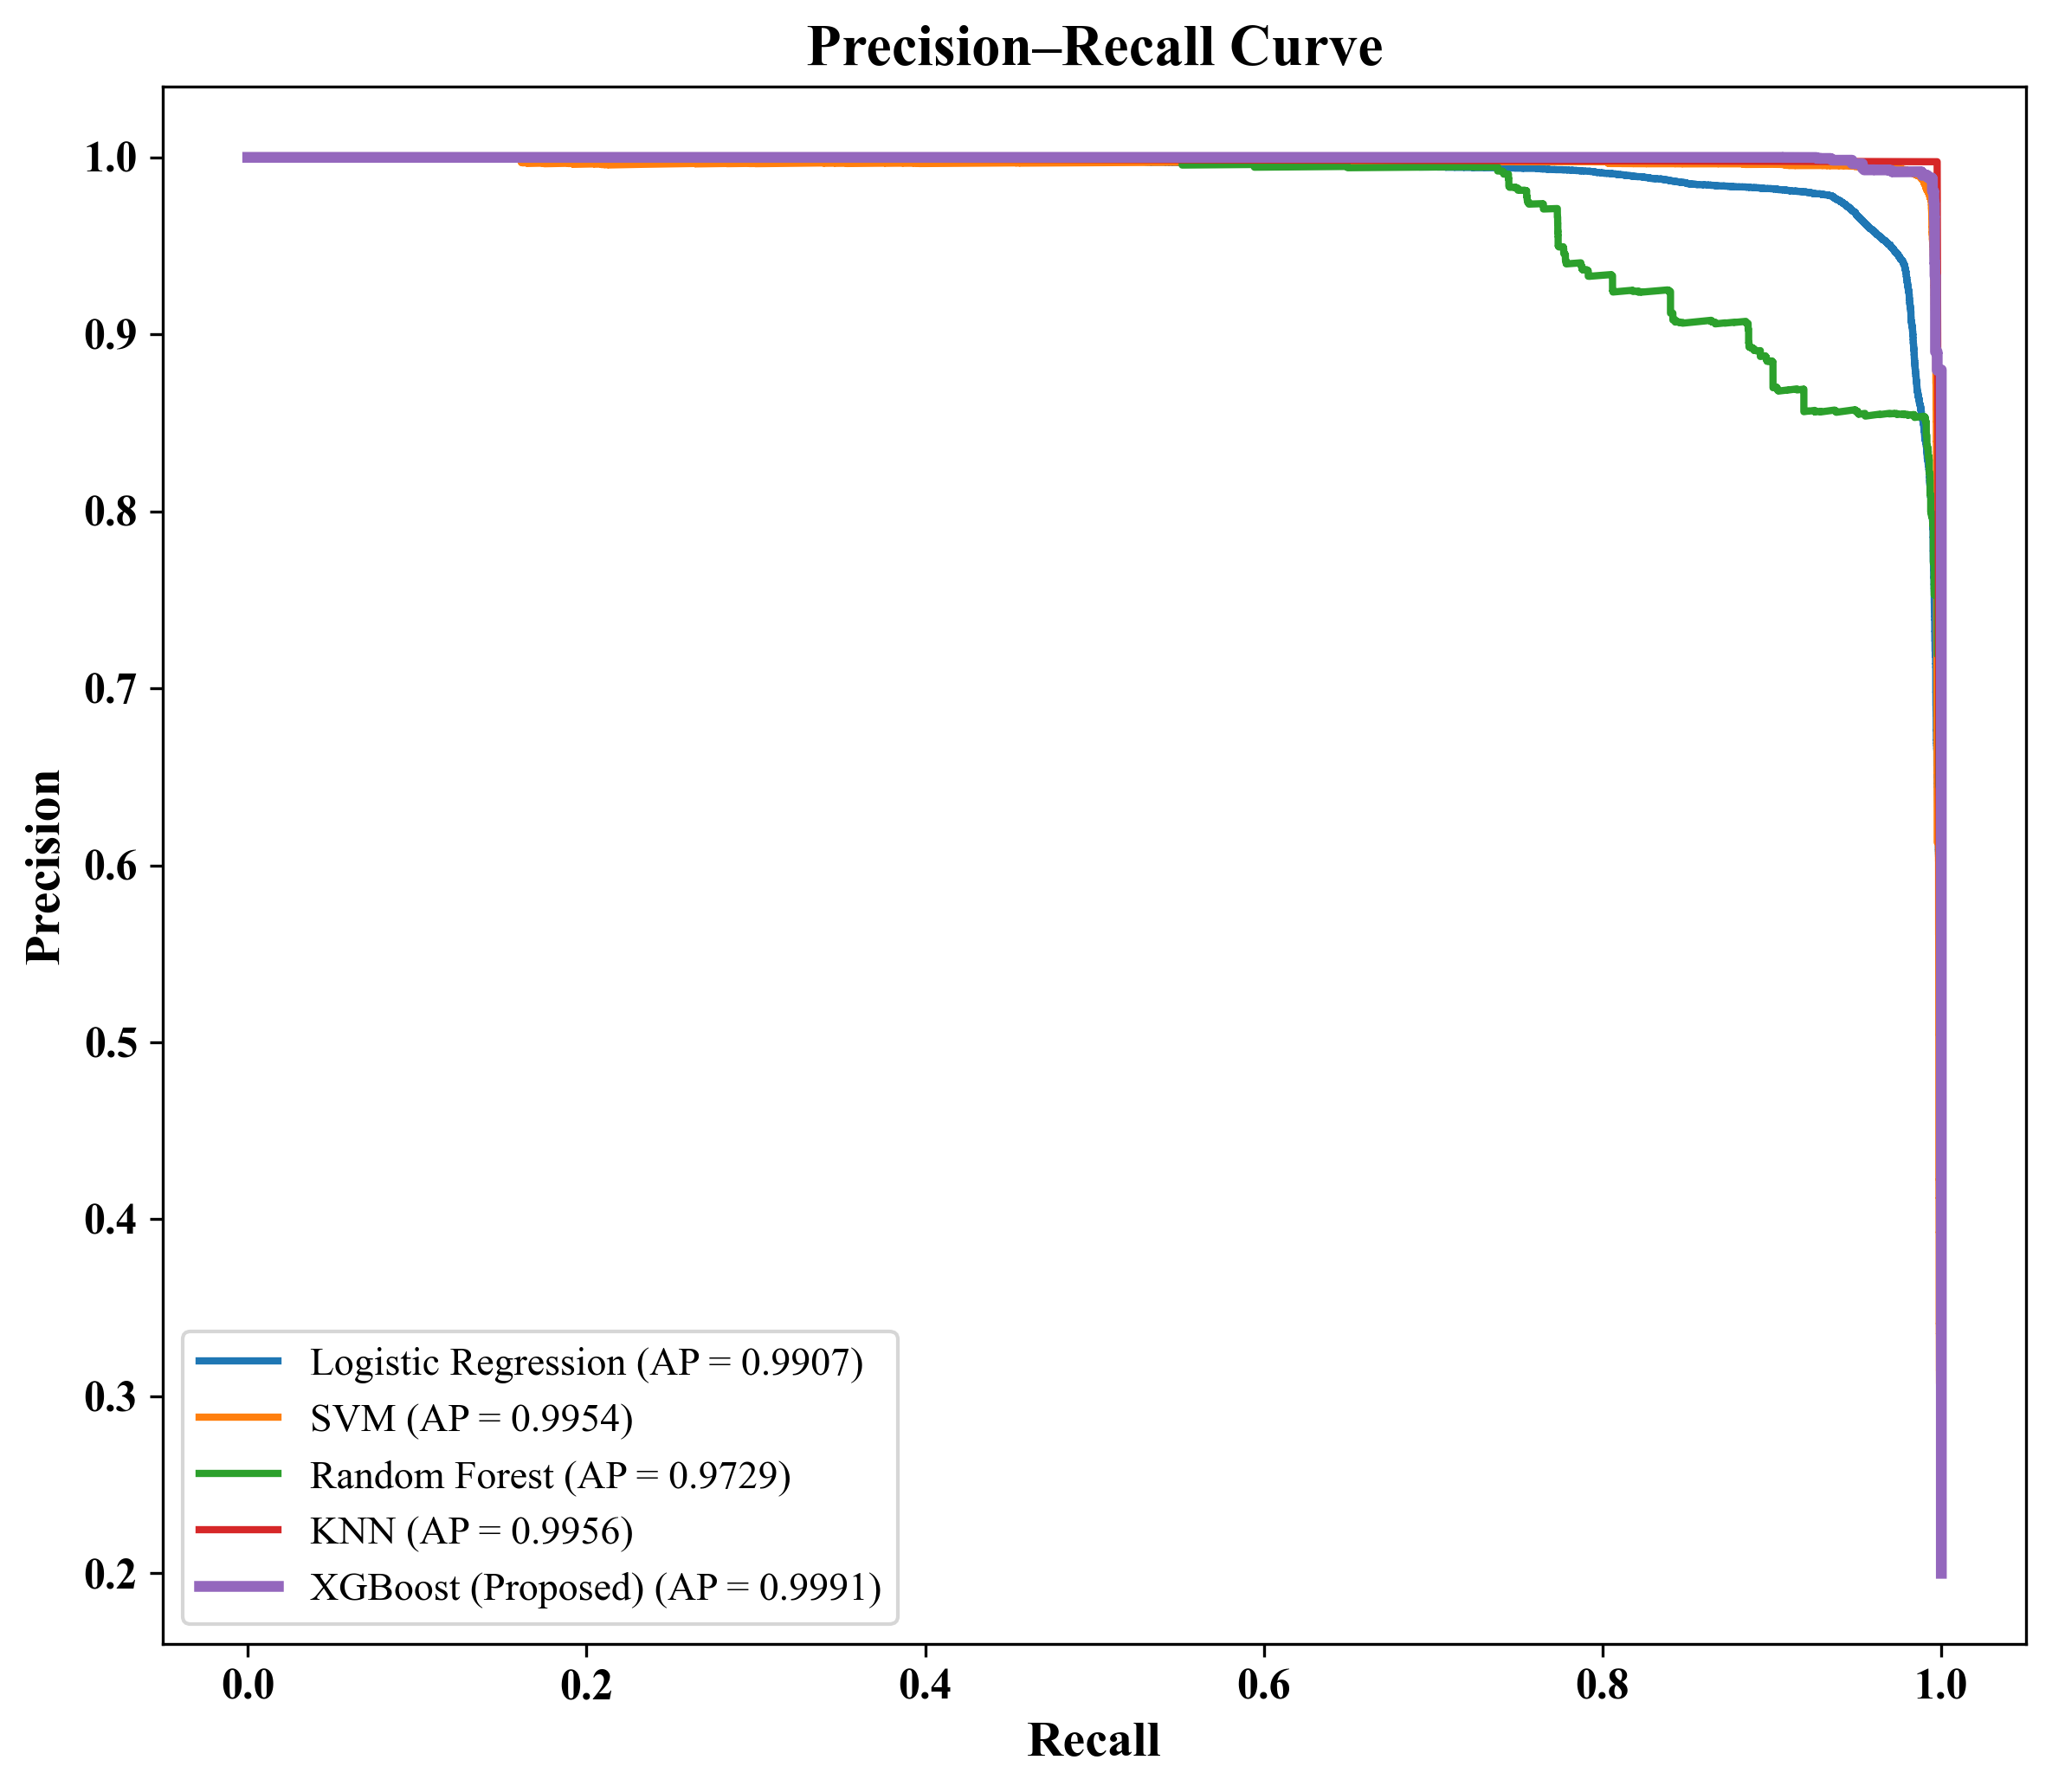

In [51]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

# Binarize labels
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 7), dpi=300)

for name, probs in models_probs.items():
    
    precision, recall, _ = precision_recall_curve(
        y_test_bin.ravel(),
        probs.ravel()
    )
    
    ap = average_precision_score(
        y_test_bin,
        probs,
        average="micro"
    )
    
    # 🔥 Change legend name here
    if name == "Proposed XGBoost":
        display_name = "XGBoost (Proposed)"
        plt.plot(
            recall,
            precision,
            linewidth=3,
            label=f"{display_name} (AP = {ap:.4f})"
        )
    else:
        plt.plot(
            recall,
            precision,
            linewidth=2,
            label=f"{name} (AP = {ap:.4f})"
        )

plt.xlabel("Recall", fontsize=14, fontweight="bold")
plt.ylabel("Precision", fontsize=14, fontweight="bold")
plt.title("Precision–Recall Curve", fontsize=16, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("all_models_pr_curve_clean.png", dpi=300, bbox_inches="tight")

plt.show()

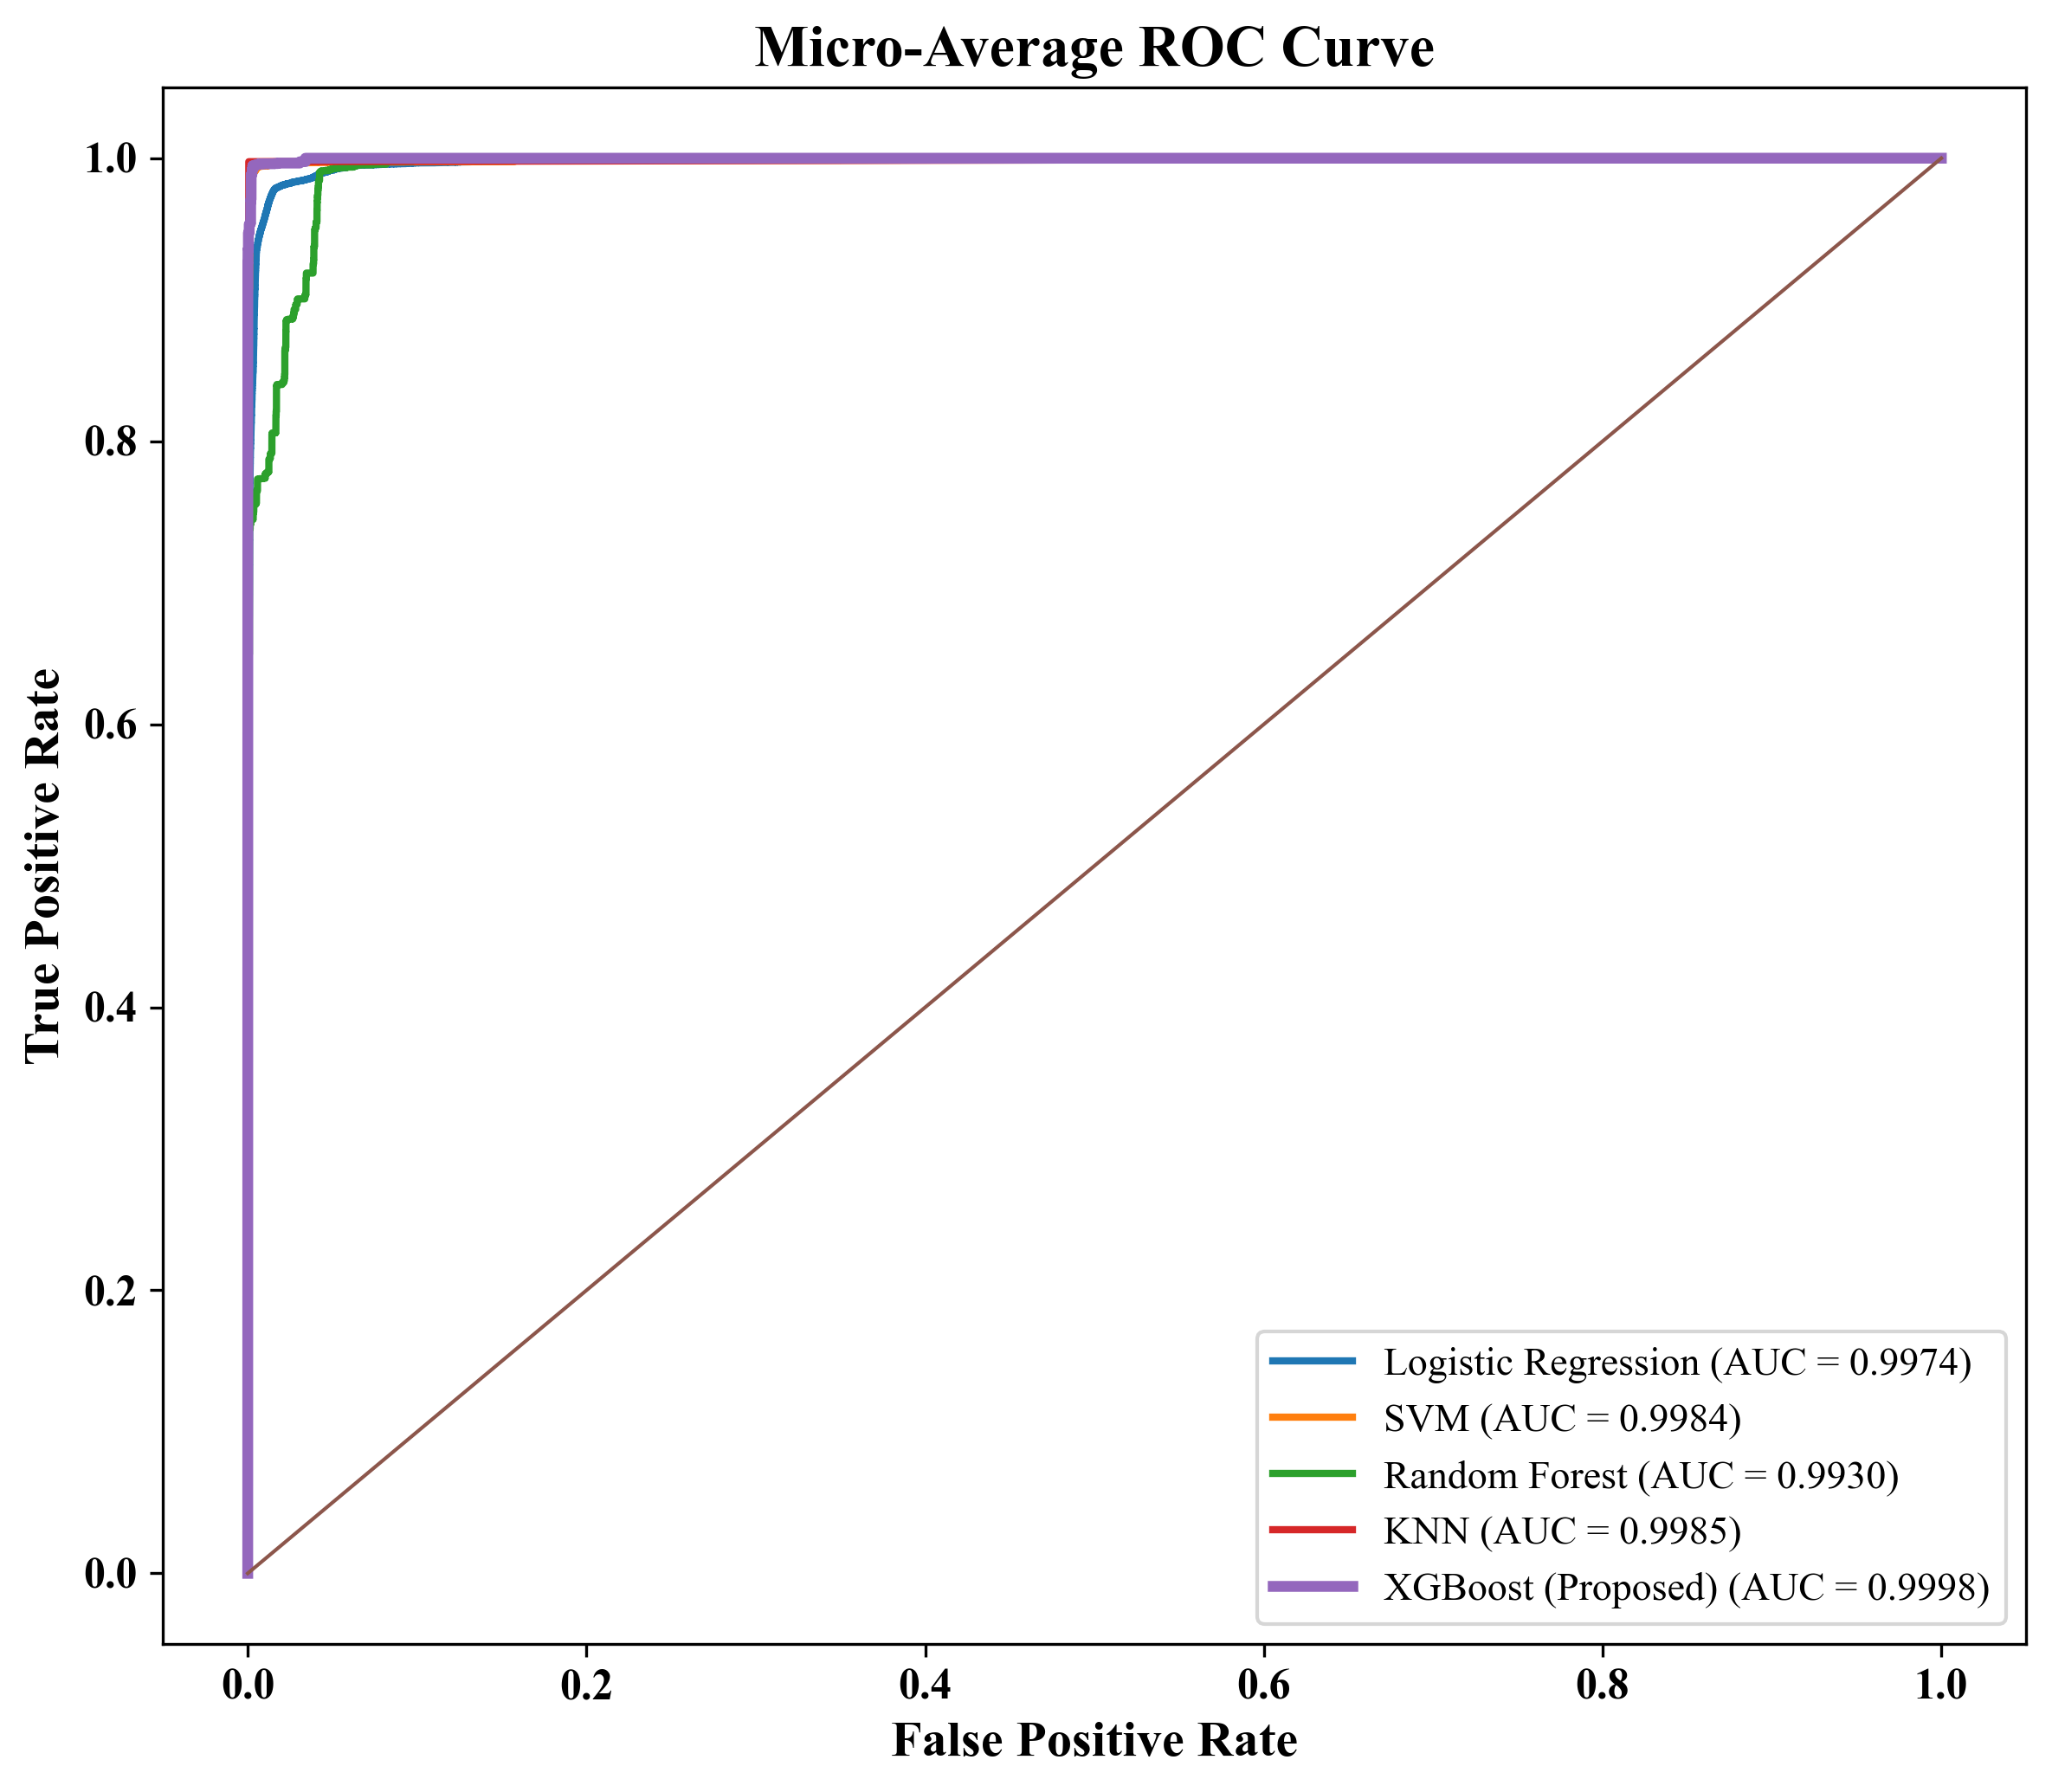

In [52]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

# Binarize labels (for multiclass)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8,7), dpi=300)

for name, probs in models_probs.items():
    
    # Micro-average ROC
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        probs.ravel()
    )
    
    roc_auc = auc(fpr, tpr)
    
    # Highlight Proposed Model
    if name == "Proposed XGBoost":
        display_name = "XGBoost (Proposed)"
        plt.plot(
            fpr,
            tpr,
            linewidth=3,
            label=f"{display_name} (AUC = {roc_auc:.4f})"
        )
    else:
        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{name} (AUC = {roc_auc:.4f})"
        )

# Diagonal reference line
plt.plot([0, 1], [0, 1], linewidth=1)

plt.xlabel("False Positive Rate", fontsize=14, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=14, fontweight="bold")
plt.title("Micro-Average ROC Curve", fontsize=16, fontweight="bold")

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("all_models_roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [2]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import xgboost
import seaborn
import scipy

# Create dictionary of versions
versions = {
    "Library": [
        "Python",
        "Pandas",
        "NumPy",
        "Scikit-learn",
        "Matplotlib",
        "Seaborn",
        "SciPy",
        "XGBoost"
    ],
    "Version": [
        sys.version.split(" ")[0],
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        matplotlib.__version__,
        seaborn.__version__,
        scipy.__version__,
        xgboost.__version__
    ]
}

# Convert to DataFrame
versions_df = pd.DataFrame(versions)

# Save to CSV
versions_df.to_csv("used_library_versions.csv", index=False)

print("Library versions saved successfully!")
print(versions_df)

Library versions saved successfully!
        Library Version
0        Python  3.9.12
1        Pandas   2.3.3
2         NumPy   2.0.2
3  Scikit-learn   1.6.1
4    Matplotlib   3.9.4
5       Seaborn  0.13.2
6         SciPy  1.13.1
7       XGBoost   2.1.4


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict
y_pred_xgb = Proposed XGBoost.predict(X_test)

# Metrics (macro for multiclass)
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average="macro")
recall = recall_score(y_test, y_pred_xgb, average="macro")
f1 = f1_score(y_test, y_pred_xgb, average="macro")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

NameError: name 'xgb_model' is not defined

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Use Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Select only XGBoost row
xgb_row = metrics_df[metrics_df["Model"] == "Proposed XGBoost"]

# Select metrics
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = xgb_row[metrics_to_plot].values.flatten()

plt.figure(figsize=(7,5), dpi=300)

bars = plt.bar(metrics_to_plot, values)

# 🔥 Add bar values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Formatting
plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.ylabel("Score", fontsize=14, fontweight="bold")

plt.title(
    "XGBoost (Proposed) Performance Metrics",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

# Save high quality
plt.savefig("xgboost_performance_metrics.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'metrics_df' is not defined

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 🔥 Predict using XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# 🔥 Calculate metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average="macro")
recall = recall_score(y_test, y_pred_xgb, average="macro")
f1 = f1_score(y_test, y_pred_xgb, average="macro")

# Store values
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(7,5), dpi=300)

bars = plt.bar(metrics, values)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.ylabel("Score", fontsize=14, fontweight="bold")
plt.title("XGBoost (Proposed) Performance Metrics", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.savefig("xgboost_performance_metrics.png", dpi=300, bbox_inches="tight")

plt.show()

NameError: name 'xgb_model' is not defined

In [5]:
import pandas as pd

# Load CSV file
metrics_df = pd.read_csv("model_comparison_metrics.csv")

# Check data
print(metrics_df.head())

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  0.959125   0.953724  0.957534  0.955320  0.996195   
1                  SVM  0.987643   0.986138  0.985007  0.985534  0.997982   
2        Random Forest  0.923257   0.933631  0.918775  0.921926  0.994577   
3     Proposed XGBoost  0.994392   0.996223  0.992352  0.994218  0.999734   

        FNR       FPR  
0  0.042466  0.010004  
1  0.014993  0.003066  
2  0.081225  0.019482  
3  0.007648  0.001605  


In [6]:
# Change the name below if needed
xgb_row = metrics_df[metrics_df["Model"] == "Proposed XGBoost"]

print(xgb_row)

              Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
3  Proposed XGBoost  0.994392   0.996223  0.992352  0.994218  0.999734   

        FNR       FPR  
3  0.007648  0.001605  


In [7]:
xgb_row = metrics_df[metrics_df["Model"] == "XGBoost (Proposed)"]

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (4,) and arg 1 with shape (0,).

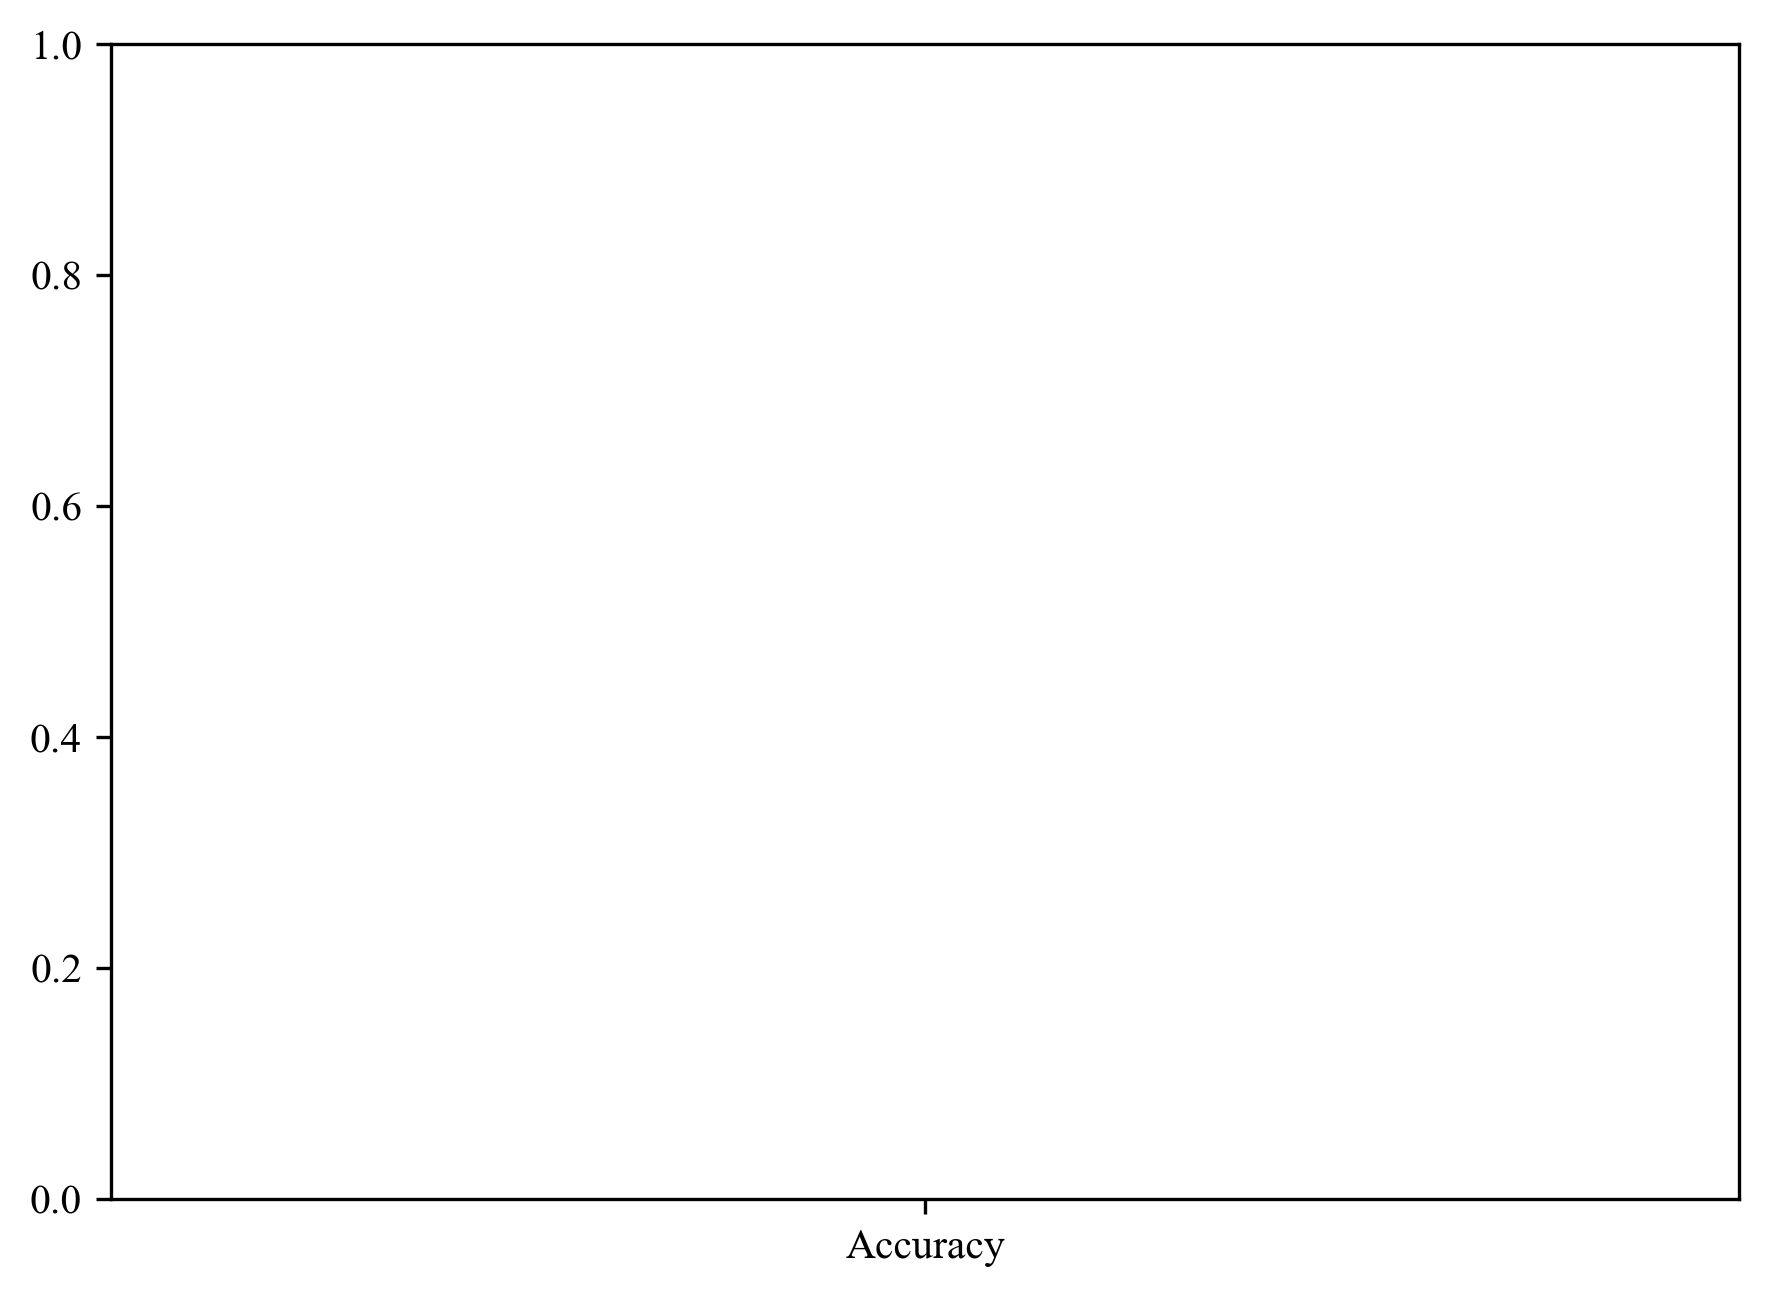

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = xgb_row[metrics_to_plot].values.flatten()

plt.figure(figsize=(7,5), dpi=300)

bars = plt.bar(metrics_to_plot, values)

# Add bar values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.xticks(fontsize=12, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")

plt.ylabel("Score", fontsize=14, fontweight="bold")
plt.title("XGBoost (Proposed) Performance Metrics", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.savefig("xgboost_performance_from_csv.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
print(metrics_df["Model"].unique())

['Logistic Regression' 'SVM' 'Random Forest' 'Proposed XGBoost']


In [11]:
xgb_row = metrics_df[metrics_df["Model"] == "XGBoost (Proposed)"]

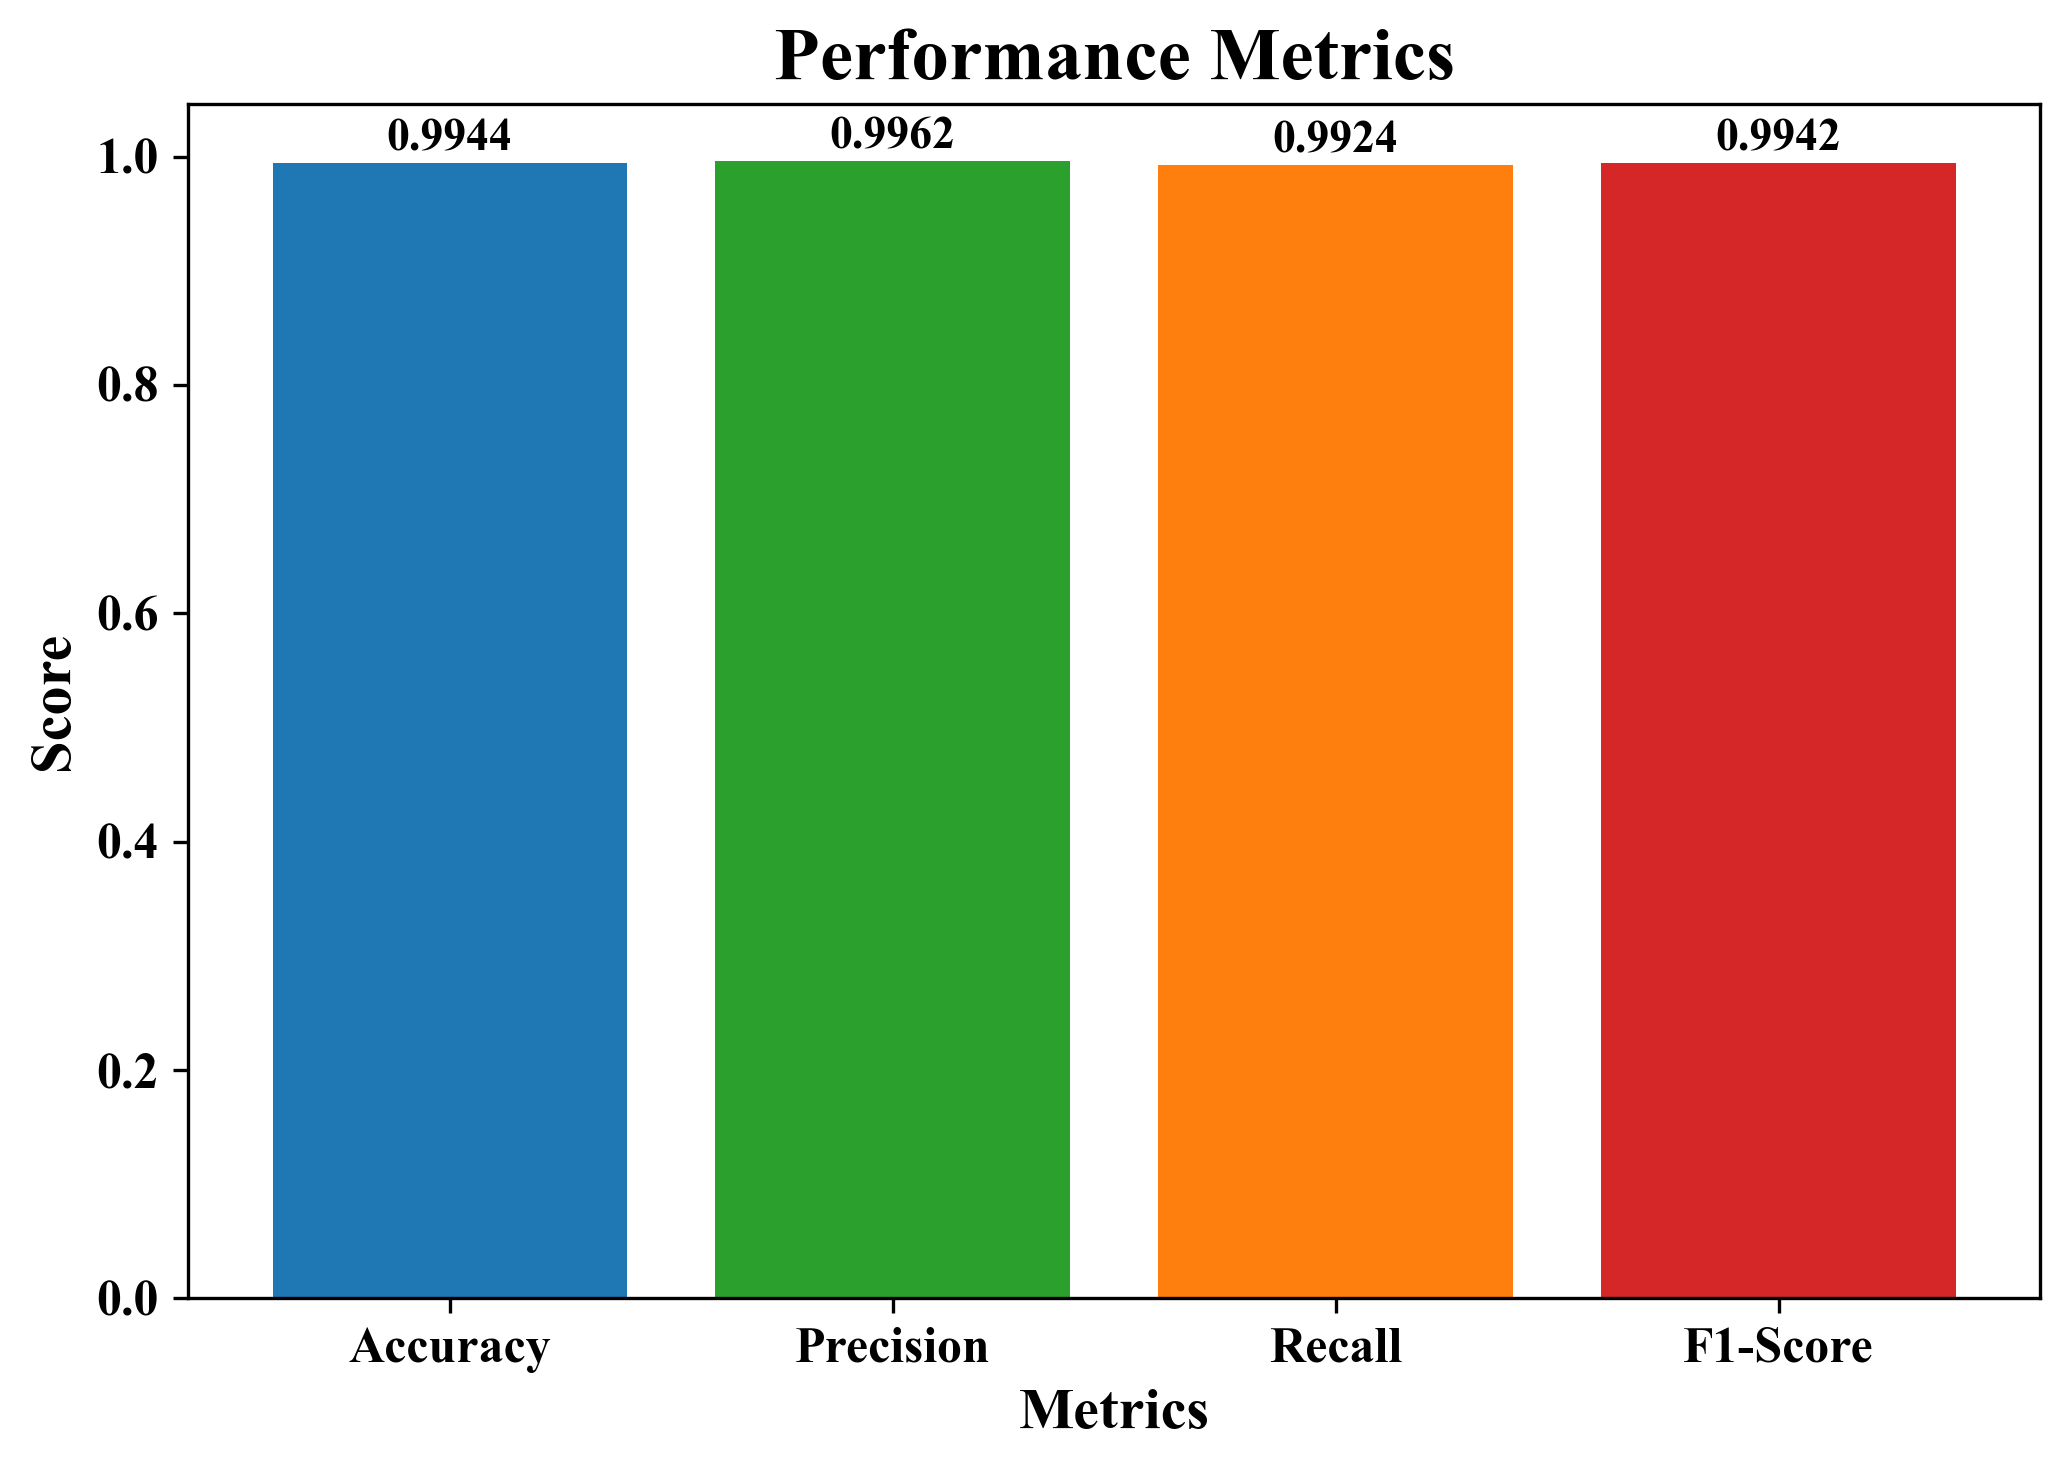

In [17]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

# 🔥 Automatically find XGBoost row
xgb_row = metrics_df[metrics_df["Model"].str.contains("XGBoost", case=False)]

if xgb_row.empty:
    print("XGBoost model not found in CSV!")
else:
    metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
    values = xgb_row[metrics_to_plot].values.flatten()

    plt.figure(figsize=(7,5), dpi=300)

    # 🎨 Add custom colors
    colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

    bars = plt.bar(metrics_to_plot, values, color=colors)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.xticks(fontsize=12, fontweight="bold")
    plt.yticks(fontsize=12, fontweight="bold")

    plt.ylabel("Score", fontsize=14, fontweight="bold")
    plt.xlabel("Metrics", fontsize=14, fontweight="bold")
    plt.title("Performance Metrics", fontsize=18, fontweight="bold")

    plt.tight_layout()
    plt.savefig("xgboost_performance_from_csv.png", dpi=300, bbox_inches="tight")

    plt.show()